# Notebook Tuning BERTopic vs LDA (Web Form Aligned)

Notebook ini dibuat untuk eksplorasi parameter tuning yang **selaras dengan form pengaturan di website Laravel** dan tetap memakai komponen inti FastAPI agar hasil konsisten saat parameter sama.

Alur yang dipakai:
1. Preprocessing
2. BERTopic loop (embedding dihitung sekali, dipakai ulang semua skenario)
3. LDA loop
4. Komparasi model
5. Ambil best parameter + retrain best model
6. Visualisasi (wordcloud, distribusi topik, CV, TD)
7. DTA (emerging, stable, declining)

Semua tahap penting mengekspor artefak CSV/JSON ke folder hasil run.

In [1]:
import itertools
import json
import math
import random
import sys
import time
from collections import Counter
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from wordcloud import WordCloud
except Exception:
    WordCloud = None

from IPython.display import display

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# Resolve fastapi root robustly whether notebook is run from repo root or fastapi folder.
CWD = Path.cwd()
candidate_roots = [
    CWD,
    CWD / "fastapi",
    CWD.parent,
    CWD.parent / "fastapi",
]

FASTAPI_ROOT = None
for candidate in candidate_roots:
    if (candidate / "app").exists():
        FASTAPI_ROOT = candidate
        break

if FASTAPI_ROOT is None:
    raise RuntimeError("Tidak menemukan folder fastapi/app. Jalankan notebook dari root project atau folder fastapi.")

if str(FASTAPI_ROOT) not in sys.path:
    sys.path.insert(0, str(FASTAPI_ROOT))

from app.ml.bertopic_trainer import BERTopicTrainer
from app.ml.evaluator import TopicEvaluator
from app.ml.lda_trainer import LDATrainer
from app.models.schemas import (
    BERTopicHyperparameters,
    HDBSCANHyperparameters,
    LDAHyperparameters,
    UMAPHyperparameters,
)
from app.services.preprocessing import TextPreprocessor

RUN_TS = datetime.now().strftime("%Y%m%d-%H%M%S")
ARTIFACT_ROOT = FASTAPI_ROOT / "data" / "results" / "notebook_tuning_web_form"
RUN_DIR = ARTIFACT_ROOT / f"run_{RUN_TS}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)

print("FASTAPI_ROOT:", FASTAPI_ROOT)
print("RUN_DIR:", RUN_DIR)
print("WordCloud available:", WordCloud is not None)

/home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/.venv-fastapi-notebook-py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FASTAPI_ROOT: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi
RUN_DIR: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260413-132545
WordCloud available: True


## 1) Konfigurasi Parameter (Selaras Form Website)

Isi `WEB_FORM_*_BASE` dengan nilai yang sama seperti di form Laravel jika ingin reproduksi 1:1.

Catatan eksplorasi:

- `*_TUNING_SPACE` akan **dibentuk ulang secara data-driven** setelah raw data dibaca di langkah preprocessing.
- Kandidat BERTopic akan selalu menyertakan `nr_topics = auto`, `8`, dan kandidat topik lebih besar.
- Kandidat LDA juga akan berisi kombinasi kecil vs besar yang masih masuk akal terhadap ukuran data.

In [2]:
# Base params yang mengikuti field form Laravel + default FastAPI current.
WEB_FORM_BERTOPIC_BASE = {
    "embedding_model": "denaya/indoSBERT-large",
    "min_topic_size": 10,
    "nr_topics": 8,
    "top_n_words": 15,
    "n_gram_range": [1, 2],
    "vectorizer_min_df": 2,
    "vectorizer_max_df": 0.95,
    "vectorizer_token_pattern": r"(?u)\b\w{3,}\b",
    "vectorizer_fallback_min_df": 1,
    "vectorizer_fallback_max_df": 1.0,
    "coherence_type": "c_v",
    "coherence_tokenization": "vectorizer",
    "coherence_dict_no_below": 3,
    "coherence_dict_no_above": 0.95,
    "reduce_outliers": True,
    "reduce_outliers_threshold_ctfidf": 0.1,
    "reduce_outliers_use_distributions": True,
    "reduce_outliers_threshold_distributions": 0.05,
    "use_mmr_representation": True,
    "mmr_diversity": 0.3,
    "embedding_batch_size": 16,
    "seed": 42,
    "umap_params": {
        "n_neighbors": 40,
        "n_components": 5,
        "min_dist": 0.0,
        "metric": "cosine",
        "random_state": 42,
    },
    "hdbscan_params": {
        "min_cluster_size": 8,
        "min_samples": 1,
        "metric": "euclidean",
        "cluster_selection_method": "eom",
    },
}

WEB_FORM_LDA_BASE = {
    "num_topics": 12,
    "passes": 20,
    "iterations": 300,
    "chunksize": 100,
    "random_state": 42,
    "alpha": "asymmetric",
    "eta": None,
    "no_below": 2,
    "no_above": 0.95,
}

# Aktifkan agar tuning space dibuat ulang otomatis setelah raw data diprofiling.
AUTO_BUILD_TUNING_SPACE_FROM_DATA = True

# Fokus evaluasi tuning: CV + TD. DTA dijalankan di tahap final (cell DTA).
RUN_DTA_IN_TUNING_LOOP = False
RUN_TEMPORAL_DIST_IN_LDA_LOOP = False

# Target jumlah topik minimum agar tidak terlalu sedikit.
MIN_TARGET_TOPICS = 8
TOPIC_SHORTFALL_PENALTY = 0.20

# Placeholder awal (akan dioverride jika AUTO_BUILD_TUNING_SPACE_FROM_DATA=True).
BERTOPIC_TUNING_SPACE = {
    "min_topic_size": [6, 8, 10, 12, 14],
    "nr_topics": ["auto", 8, 10, 12, 14, 16],
    "top_n_words": [12, 15, 20],
    "n_gram_range": [(1, 1), (1, 2)],
    "umap_n_neighbors": [10, 20, 30, 45],
    "umap_n_components": [5, 8, 10],
    "umap_metric": ["cosine"],
    "hdbscan_min_cluster_size": [6, 8, 10, 12, 14],
    "hdbscan_min_samples": [1, 2],
    "hdbscan_metric": ["euclidean"],
}

LDA_TUNING_SPACE = {
    "num_topics": [8, 10, 12, 14, 16],
    "passes": [10, 15, 25],
    "iterations": [200, 300, 400],
    "chunksize": [80, 100, 150],
    "random_state": [42],
    "alpha": ["asymmetric", "symmetric", 0.1],
    "eta": [None, "symmetric", 0.1],
    "no_below": [2, 3, 4],
    "no_above": [0.85, 0.90, 0.95],
}

# Sampling cap agar jumlah eksperimen tetap realistis saat kombinasinya besar.
MAX_SCENARIOS = 20
MAX_BERTOPIC_SCENARIOS = MAX_SCENARIOS
MAX_LDA_SCENARIOS = MAX_SCENARIOS
SCENARIO_SEED = 42

print("BERTopic base params loaded")
print("LDA base params loaded")
print("AUTO_BUILD_TUNING_SPACE_FROM_DATA:", AUTO_BUILD_TUNING_SPACE_FROM_DATA)
print("RUN_DTA_IN_TUNING_LOOP:", RUN_DTA_IN_TUNING_LOOP)
print("RUN_TEMPORAL_DIST_IN_LDA_LOOP:", RUN_TEMPORAL_DIST_IN_LDA_LOOP)
print("MIN_TARGET_TOPICS:", MIN_TARGET_TOPICS)
print("MAX_SCENARIOS:", MAX_SCENARIOS)
print("MAX_BERTOPIC_SCENARIOS:", MAX_BERTOPIC_SCENARIOS)
print("MAX_LDA_SCENARIOS:", MAX_LDA_SCENARIOS)

BERTopic base params loaded
LDA base params loaded
AUTO_BUILD_TUNING_SPACE_FROM_DATA: True
RUN_DTA_IN_TUNING_LOOP: False
RUN_TEMPORAL_DIST_IN_LDA_LOOP: False
MIN_TARGET_TOPICS: 8
MAX_SCENARIOS: 20
MAX_BERTOPIC_SCENARIOS: 20
MAX_LDA_SCENARIOS: 20


## 2) Preprocessing + Export Before/After CSV

Bagian ini meniru aturan pipeline preprocessing FastAPI (drop null abstract, dedup abstract, filter year, dual output cleaned/processed), lalu ekspor CSV per tahap untuk pelaporan.

In [3]:
preprocessor = TextPreprocessor(
    remove_stopwords=True,
    use_stemming=True,
    min_word_length=3,
    language="indonesian",
)


def _normalize_dataset_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    normalized_map = {}
    for col in df.columns:
        normalized = str(col).strip().lower()
        normalized = normalized.replace("%", "pct")
        normalized = "".join(ch if ch.isalnum() else "_" for ch in normalized)
        while "__" in normalized:
            normalized = normalized.replace("__", "_")
        normalized = normalized.strip("_")
        normalized_map[col] = normalized or "col"

    df = df.rename(columns=normalized_map)

    aliases = {
        "id": ["id", "skripsi_id"],
        "title": ["title", "judul"],
        "author": ["author", "penulis"],
        "year": ["year", "tahun"],
        "abstract": ["abstract", "abstrak"],
        "conclusion": ["conclusion", "kesimpulan"],
        "keywords": ["keywords", "kata_kunci"],
        "url": ["url"],
    }

    for target, cols in aliases.items():
        if target in df.columns:
            continue
        existing = [c for c in cols if c in df.columns]
        if existing:
            df[target] = df[existing[0]]

    if "id" not in df.columns:
        df["id"] = range(1, len(df) + 1)

    for text_col in ["title", "abstract", "conclusion"]:
        if text_col in df.columns:
            df[text_col] = (
                df[text_col]
                .fillna("")
                .astype(str)
                .str.replace(r"\s+", " ", regex=True)
                .str.strip()
            )

    return df


def _load_raw_from_csv_only() -> tuple[pd.DataFrame, str]:
    raw_csv_path = FASTAPI_ROOT / "data" / "raw" / "raw_data.csv"
    if not raw_csv_path.exists():
        raise FileNotFoundError(f"File raw data tidak ditemukan: {raw_csv_path}")

    df = pd.read_csv(raw_csv_path)
    return _normalize_dataset_columns(df), f"csv:{raw_csv_path}"


raw_df, data_source = _load_raw_from_csv_only()
if "abstract" not in raw_df.columns:
    raise ValueError("Kolom abstract/abstrak tidak ditemukan pada sumber data.")

raw_path = RUN_DIR / "preprocess_step0_raw_source.csv"
raw_df.to_csv(raw_path, index=False)

stage_df = raw_df.copy()
dropna_mask = stage_df["abstract"].isna() | (stage_df["abstract"].astype(str).str.strip() == "")
dropna_df = stage_df.loc[dropna_mask].copy()
stage_df = stage_df.loc[~dropna_mask].copy()

duplicate_mask = stage_df.duplicated(subset=["abstract"], keep="first")
duplicate_df = stage_df.loc[duplicate_mask].copy()
stage_df = stage_df.loc[~duplicate_mask].copy()

if "year" not in stage_df.columns:
    stage_df["year"] = pd.NA

year_series = pd.to_numeric(stage_df["year"], errors="coerce")
year_mask = year_series.between(2018, 2026)
year_drop_df = stage_df.loc[~year_mask].copy()
stage_df = stage_df.loc[year_mask].copy()
stage_df["year"] = pd.to_numeric(stage_df["year"], errors="coerce").astype("Int64")
stage_df = stage_df.reset_index(drop=True)

filtered_path = RUN_DIR / "preprocess_step1_filtered.csv"
stage_df.to_csv(filtered_path, index=False)

ids_before = set(stage_df["id"].astype(int).tolist()) if "id" in stage_df.columns else set()

preprocessed_df = preprocessor.preprocess_dataframe(
    stage_df,
    text_column="abstract",
    title_column="title",
    conclusion_column="conclusion",
)

ids_after = set(preprocessed_df["id"].astype(int).tolist()) if "id" in preprocessed_df.columns else set()
empty_after_ids = ids_before - ids_after
empty_after_df = stage_df[stage_df["id"].isin(empty_after_ids)].copy() if empty_after_ids else stage_df.head(0).copy()

dual_path = RUN_DIR / "preprocess_step2_dual_preprocessed.csv"
preprocessed_df.to_csv(dual_path, index=False)

before_cols = [c for c in ["id", "title", "year", "abstract", "conclusion"] if c in stage_df.columns]
after_cols = [c for c in ["id", "combined_text", "cleaned_text", "processed_text"] if c in preprocessed_df.columns]

before_after_df = stage_df[before_cols].merge(preprocessed_df[after_cols], on="id", how="inner")
before_after_df["token_before"] = before_after_df["abstract"].fillna("").astype(str).str.split().apply(len)
before_after_df["token_cleaned"] = before_after_df["cleaned_text"].fillna("").astype(str).str.split().apply(len)
before_after_df["token_processed"] = before_after_df["processed_text"].fillna("").astype(str).str.split().apply(len)
before_after_df["token_reduction_processed"] = before_after_df["token_before"] - before_after_df["token_processed"]

before_after_path = RUN_DIR / "preprocess_step3_before_after_audit.csv"
before_after_df.to_csv(before_after_path, index=False)

drop_summary_df = pd.DataFrame([
    {"reason": "dropna_abstract", "count": int(len(dropna_df))},
    {"reason": "duplicate_abstract", "count": int(len(duplicate_df))},
    {"reason": "year_out_of_range", "count": int(len(year_drop_df))},
    {"reason": "empty_after_preprocessing", "count": int(len(empty_after_df))},
])
drop_summary_path = RUN_DIR / "preprocess_drop_summary.csv"
drop_summary_df.to_csv(drop_summary_path, index=False)

if preprocessed_df.empty:
    raise ValueError("Dataset kosong setelah preprocessing.")

bertopic_docs = preprocessed_df["cleaned_text"].astype(str).tolist()
lda_docs = preprocessed_df["processed_text"].astype(str).tolist()
document_ids = preprocessed_df["id"].astype(int).tolist()
timestamps = preprocessed_df["year"].astype(int).tolist() if preprocessed_df["year"].notna().all() else None

# Profiling data untuk menentukan ruang eksplorasi parameter secara masuk akal.
doc_count = int(len(preprocessed_df))
processed_tokens = preprocessed_df["processed_text"].astype(str).str.split().apply(len)
cleaned_tokens = preprocessed_df["cleaned_text"].astype(str).str.split().apply(len)

doc_profile = {
    "source": data_source,
    "raw_rows": int(len(raw_df)),
    "filtered_rows": int(len(stage_df)),
    "final_rows": doc_count,
    "duplicate_abstract_removed": int(len(duplicate_df)),
    "year_min": int(preprocessed_df["year"].min()) if "year" in preprocessed_df.columns and preprocessed_df["year"].notna().any() else None,
    "year_max": int(preprocessed_df["year"].max()) if "year" in preprocessed_df.columns and preprocessed_df["year"].notna().any() else None,
    "processed_token_p25": float(processed_tokens.quantile(0.25)),
    "processed_token_p50": float(processed_tokens.quantile(0.50)),
    "processed_token_p75": float(processed_tokens.quantile(0.75)),
    "cleaned_token_p50": float(cleaned_tokens.quantile(0.50)),
}

doc_profile_df = pd.DataFrame([doc_profile])
doc_profile_path = RUN_DIR / "raw_profile_summary.csv"
doc_profile_df.to_csv(doc_profile_path, index=False)

if AUTO_BUILD_TUNING_SPACE_FROM_DATA:
    min_topics_target = int(globals().get("MIN_TARGET_TOPICS", 8))

    large_topic = int(min(14, max(10, round(doc_count / 35))))
    mid_topic = int(min(12, max(8, round(doc_count / 45))))
    topic_candidates = sorted(set([8, 10, 12, 14, mid_topic, large_topic]))
    topic_candidates = [int(v) for v in topic_candidates if int(v) >= min_topics_target]

    bertopic_nr_topics = ["auto"] + topic_candidates

    min_topic_size_candidates = sorted(set([
        6,
        8,
        10,
        int(max(8, round(doc_count / 70))),
        int(max(10, round(doc_count / 55))),
    ]))
    min_topic_size_candidates = [int(max(6, min(14, v))) for v in min_topic_size_candidates]

    hdbscan_cluster_candidates = sorted(set([
        6,
        8,
        10,
        int(max(8, round(doc_count / 65))),
        int(max(10, round(doc_count / 50))),
    ]))
    hdbscan_cluster_candidates = [int(max(6, min(14, v))) for v in hdbscan_cluster_candidates]

    lda_topic_candidates = sorted(set([8, 10, 12, 14] + topic_candidates))

    BERTOPIC_TUNING_SPACE = {
        "min_topic_size": min_topic_size_candidates,
        "nr_topics": bertopic_nr_topics,
        "top_n_words": [15, 20],
        "n_gram_range": [(1, 1), (1, 2)],
        "umap_n_neighbors": [15, 30, 45],
        "umap_n_components": [5, 8],
        "umap_metric": ["cosine"],
        "hdbscan_min_cluster_size": hdbscan_cluster_candidates,
        "hdbscan_min_samples": [1, 2],
        "hdbscan_metric": ["euclidean"],
    }

    LDA_TUNING_SPACE = {
        "num_topics": lda_topic_candidates,
        "passes": [15, 25],
        "iterations": [200, 300],
        "chunksize": [100, 150],
        "random_state": [42],
        "alpha": ["asymmetric", "symmetric"],
        "eta": [None, "symmetric"],
        "no_below": [2, 3],
        "no_above": [0.90, 0.95],
    }

    MAX_BERTOPIC_SCENARIOS = int(min(16, max(10, doc_count // 45)))
    MAX_LDA_SCENARIOS = int(min(18, max(12, doc_count // 30)))

tuning_space_payload = {
    "doc_profile": doc_profile,
    "bertopic_tuning_space": BERTOPIC_TUNING_SPACE,
    "lda_tuning_space": LDA_TUNING_SPACE,
    "max_bertopic_scenarios": int(MAX_BERTOPIC_SCENARIOS),
    "max_lda_scenarios": int(MAX_LDA_SCENARIOS),
    "seed": int(SCENARIO_SEED),
}
tuning_space_path = RUN_DIR / "tuning_space_selected.json"
with open(tuning_space_path, "w", encoding="utf-8") as f:
    json.dump(tuning_space_payload, f, ensure_ascii=False, indent=2)

print("Data source:", data_source)
print("Raw rows:", len(raw_df))
print("Filtered rows:", len(stage_df))
print("Final preprocessed rows:", len(preprocessed_df))
print("MAX_BERTOPIC_SCENARIOS:", MAX_BERTOPIC_SCENARIOS)
print("MAX_LDA_SCENARIOS:", MAX_LDA_SCENARIOS)
print("BERTopic nr_topics candidates:", BERTOPIC_TUNING_SPACE.get("nr_topics"))
print("LDA num_topics candidates:", LDA_TUNING_SPACE.get("num_topics"))
display(drop_summary_df)
display(doc_profile_df)
display(before_after_df.head(3))

2026-04-13 13:25:45.403 | INFO     | app.services.preprocessing:preprocess_dataframe:161 - Preprocessing 473 documents (dual pipeline)...
2026-04-13 13:25:45.404 | INFO     | app.services.preprocessing:preprocess_dataframe:175 -   Building combined_text (title + abstract + optional conclusion)...
2026-04-13 13:25:45.536 | INFO     | app.services.preprocessing:preprocess_dataframe:181 -   [BERTopic pipeline] Soft clean (no stopword removal, no stemming)...
2026-04-13 13:25:45.664 | INFO     | app.services.preprocessing:preprocess_dataframe:184 -   [LDA pipeline] Full clean + stopword removal + stemming...
2026-04-13 13:30:19.190 | INFO     | app.services.preprocessing:preprocess_dataframe:200 - Preprocessing complete. 473 documents remaining.
2026-04-13 13:30:19.204 | INFO     | app.services.preprocessing:preprocess_dataframe:201 -   cleaned_text avg words: 285.1
2026-04-13 13:30:19.219 | INFO     | app.services.preprocessing:preprocess_dataframe:204 -   processed_text avg words: 160.6


Data source: csv:/home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/raw/raw_data.csv
Raw rows: 474
Filtered rows: 473
Final preprocessed rows: 473
MAX_BERTOPIC_SCENARIOS: 10
MAX_LDA_SCENARIOS: 15
BERTopic nr_topics candidates: ['auto', 8, 10, 11, 12, 14]
LDA num_topics candidates: [8, 10, 11, 12, 14]


,reason,count
0,dropna_abstract,0
1,duplicate_abstract,1
2,year_out_of_range,0
3,empty_after_preprocessing,0


,source,raw_rows,filtered_rows,final_rows,duplicate_abstract_removed,year_min,year_max,processed_token_p25,processed_token_p50,processed_token_p75,cleaned_token_p50
0,csv:/home/galih/MySkripsi/- Aplikasi/my-skrips...,474,473,473,1,2018,2026,107.0,146.0,200.0,270.0


,id,title,year,abstract,conclusion,combined_text,cleaned_text,processed_text,token_before,token_cleaned,token_processed,token_reduction_processed
0,1,"Perbandingan Metode Grid Search, Random Search...",2026,Layanan perpajakan digital Website Coretax yan...,Berdasarkan hasil penelitian yang telah dilaku...,"Perbandingan Metode Grid Search, Random Search...","perbandingan metode grid search, random search...",banding grid search random search bayesian opt...,177,428,230,-53
1,2,Klasterisasi Produktivitas Pertanian di Kabupa...,2026,Produktivitas pertanian padi merupakan aspek p...,"Berdasarkan hasil penelitian, perancangan, dan...",Klasterisasi Produktivitas Pertanian di Kabupa...,klasterisasi produktivitas pertanian di kabupa...,klasterisasi produktivitas tani kabupaten bata...,194,537,306,-112
2,3,Implementasi Algoritma Holt-Winters Exponentia...,2026,Kunjungan wisatawan pada destinasi wisata cend...,Berdasarkan hasil penelitian mengenai implemen...,Implementasi Algoritma Holt-Winters Exponentia...,implementasi algoritma holt-winters exponentia...,implementasi algoritma holt winters exponentia...,148,367,215,-67


In [4]:
def _to_token_array(text):
    if pd.isna(text):
        return []
    return [token for token in str(text).split() if token]

token_array_table_df = before_after_df.copy()

token_array_table_df["token_array - input bertopic"] = token_array_table_df["cleaned_text"].apply(_to_token_array)
token_array_table_df["token_array - input lda"] = token_array_table_df["processed_text"].apply(_to_token_array)
token_array_table_df["jumlah token - input bertopic"] = token_array_table_df["token_array - input bertopic"].apply(len)
token_array_table_df["jumlah token - input lda"] = token_array_table_df["token_array - input lda"].apply(len)

display_columns = [
    col
    for col in [
        "id",
        "title",
        "year",
        "token_array - input bertopic",
        "token_array - input lda",
        "jumlah token - input bertopic",
        "jumlah token - input lda",
    ]
    if col in token_array_table_df.columns
]

print("Preview tabel token array untuk input BERTopic dan input LDA:")
display(token_array_table_df[display_columns].head(5))

# Simpan versi CSV agar mudah dipakai di laporan (array diserialisasi ke JSON string).
token_array_export_df = token_array_table_df[display_columns].copy()
if "token_array - input bertopic" in token_array_export_df.columns:
    token_array_export_df["token_array - input bertopic"] = token_array_export_df["token_array - input bertopic"].apply(
        lambda values: json.dumps(values, ensure_ascii=False)
    )
if "token_array - input lda" in token_array_export_df.columns:
    token_array_export_df["token_array - input lda"] = token_array_export_df["token_array - input lda"].apply(
        lambda values: json.dumps(values, ensure_ascii=False)
    )

token_array_table_path = RUN_DIR / "preprocess_step3_token_array_input_bertopic_lda.csv"
token_array_export_df.to_csv(token_array_table_path, index=False)
print("Token array table saved:", token_array_table_path)

Preview tabel token array untuk input BERTopic dan input LDA:


,id,title,year,token_array - input bertopic,token_array - input lda,jumlah token - input bertopic,jumlah token - input lda
0,1,"Perbandingan Metode Grid Search, Random Search...",2026,"[perbandingan, metode, grid, search,, random, ...","[banding, grid, search, random, search, bayesi...",428,230
1,2,Klasterisasi Produktivitas Pertanian di Kabupa...,2026,"[klasterisasi, produktivitas, pertanian, di, k...","[klasterisasi, produktivitas, tani, kabupaten,...",537,306
2,3,Implementasi Algoritma Holt-Winters Exponentia...,2026,"[implementasi, algoritma, holt-winters, expone...","[implementasi, algoritma, holt, winters, expon...",367,215
3,4,Pengembangan Aplikasi Text Mining untuk Mengek...,2026,"[pengembangan, aplikasi, text, mining, untuk, ...","[kembang, aplikasi, text, mining, ekstraksi, i...",254,152
4,5,Implementasi LSTM Untuk Prediksi Konsumsi Kalo...,2026,"[implementasi, lstm, untuk, prediksi, konsumsi...","[implementasi, lstm, prediksi, konsumsi, kalor...",430,270


Token array table saved: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260413-132545/preprocess_step3_token_array_input_bertopic_lda.csv


## 3) Loop Tuning BERTopic dan LDA

- BERTopic: embedding dihitung sekali di awal, lalu dipakai ulang ke semua skenario.
- LDA: loop standar per skenario.
- DTA tidak dihitung di loop agar tuning lebih cepat; DTA dijalankan di tahap final.
- Semua hasil loop diekspor ke CSV.

In [5]:
def build_combinations(space_dict):
    keys = list(space_dict.keys())
    value_lists = []
    for key in keys:
        value = space_dict[key]
        if isinstance(value, list):
            value_lists.append(value)
        else:
            value_lists.append([value])
    return [dict(zip(keys, values)) for values in itertools.product(*value_lists)]


def sample_combinations(combos, max_items, seed):
    if max_items is None or len(combos) <= max_items:
        return combos
    rng = random.Random(seed)
    return rng.sample(combos, k=max_items)


def normalize_nr_topics(value):
    if value is None:
        return None
    text = str(value).strip().lower()
    if text in {"", "none", "null"}:
        return None
    if text == "auto":
        return "auto"
    return max(8, int(float(text)))


def apply_topic_floor_penalty(score, num_topics, min_topics=8, penalty=0.20):
    base_score = float(score or 0.0)
    if num_topics is None:
        return base_score, False
    try:
        topic_count = int(num_topics)
    except (TypeError, ValueError):
        return base_score, False

    if topic_count >= int(min_topics):
        return base_score, False

    shortfall = int(min_topics) - topic_count
    multiplier = max(0.0, 1.0 - float(penalty) * shortfall)
    return base_score * multiplier, True


def make_bertopic_params(combo):
    ngram = combo["n_gram_range"]
    if not isinstance(ngram, (list, tuple)) or len(ngram) != 2:
        raise ValueError(f"Invalid n_gram_range: {ngram}")

    return BERTopicHyperparameters(
        embedding_model=WEB_FORM_BERTOPIC_BASE["embedding_model"],
        min_topic_size=int(combo["min_topic_size"]),
        nr_topics=normalize_nr_topics(combo["nr_topics"]),
        top_n_words=int(combo["top_n_words"]),
        n_gram_range=[int(ngram[0]), int(ngram[1])],
        vectorizer_min_df=WEB_FORM_BERTOPIC_BASE["vectorizer_min_df"],
        vectorizer_max_df=WEB_FORM_BERTOPIC_BASE["vectorizer_max_df"],
        vectorizer_token_pattern=WEB_FORM_BERTOPIC_BASE["vectorizer_token_pattern"],
        vectorizer_fallback_min_df=WEB_FORM_BERTOPIC_BASE["vectorizer_fallback_min_df"],
        vectorizer_fallback_max_df=WEB_FORM_BERTOPIC_BASE["vectorizer_fallback_max_df"],
        coherence_type=WEB_FORM_BERTOPIC_BASE["coherence_type"],
        coherence_tokenization=WEB_FORM_BERTOPIC_BASE["coherence_tokenization"],
        coherence_dict_no_below=WEB_FORM_BERTOPIC_BASE["coherence_dict_no_below"],
        coherence_dict_no_above=WEB_FORM_BERTOPIC_BASE["coherence_dict_no_above"],
        reduce_outliers=WEB_FORM_BERTOPIC_BASE["reduce_outliers"],
        reduce_outliers_threshold_ctfidf=WEB_FORM_BERTOPIC_BASE["reduce_outliers_threshold_ctfidf"],
        reduce_outliers_use_distributions=WEB_FORM_BERTOPIC_BASE["reduce_outliers_use_distributions"],
        reduce_outliers_threshold_distributions=WEB_FORM_BERTOPIC_BASE["reduce_outliers_threshold_distributions"],
        use_mmr_representation=WEB_FORM_BERTOPIC_BASE["use_mmr_representation"],
        mmr_diversity=WEB_FORM_BERTOPIC_BASE["mmr_diversity"],
        embedding_batch_size=WEB_FORM_BERTOPIC_BASE["embedding_batch_size"],
        seed=WEB_FORM_BERTOPIC_BASE["seed"],
        umap_params=UMAPHyperparameters(
            n_neighbors=int(combo["umap_n_neighbors"]),
            n_components=int(combo["umap_n_components"]),
            min_dist=float(WEB_FORM_BERTOPIC_BASE["umap_params"]["min_dist"]),
            metric=str(combo["umap_metric"]),
            random_state=int(WEB_FORM_BERTOPIC_BASE["umap_params"]["random_state"]),
        ),
        hdbscan_params=HDBSCANHyperparameters(
            min_cluster_size=int(combo["hdbscan_min_cluster_size"]),
            min_samples=None if combo["hdbscan_min_samples"] is None else int(combo["hdbscan_min_samples"]),
            metric=str(combo["hdbscan_metric"]),
            cluster_selection_method=WEB_FORM_BERTOPIC_BASE["hdbscan_params"]["cluster_selection_method"],
        ),
    )


def make_lda_params(combo):
    return LDAHyperparameters(
        num_topics=int(combo["num_topics"]),
        passes=int(combo["passes"]),
        iterations=int(combo["iterations"]),
        chunksize=int(combo["chunksize"]),
        random_state=int(combo["random_state"]),
        alpha=combo["alpha"],
        eta=combo["eta"],
        no_below=int(combo["no_below"]),
        no_above=float(combo["no_above"]),
    )


all_bertopic_combos = build_combinations(BERTOPIC_TUNING_SPACE)
all_lda_combos = build_combinations(LDA_TUNING_SPACE)

all_bertopic_combos = [
    combo
    for combo in all_bertopic_combos
    if normalize_nr_topics(combo.get("nr_topics")) in {None, "auto"}
    or int(normalize_nr_topics(combo.get("nr_topics"))) >= int(MIN_TARGET_TOPICS)
]
all_lda_combos = [
    combo
    for combo in all_lda_combos
    if int(combo.get("num_topics", 0)) >= int(MIN_TARGET_TOPICS)
]

if not all_bertopic_combos:
    raise ValueError("Tidak ada kombinasi BERTopic setelah filter MIN_TARGET_TOPICS.")
if not all_lda_combos:
    raise ValueError("Tidak ada kombinasi LDA setelah filter MIN_TARGET_TOPICS.")

max_scenarios_hint = int(
    globals().get("MAX_SCENARIOS", max(int(MAX_BERTOPIC_SCENARIOS), int(MAX_LDA_SCENARIOS)))
)
target_scenarios = int(min(len(all_bertopic_combos), len(all_lda_combos), max_scenarios_hint))
if target_scenarios <= 0:
    raise ValueError("Target skenario tuning tidak valid.")

sampled_bertopic_combos = sample_combinations(all_bertopic_combos, target_scenarios, SCENARIO_SEED)
sampled_lda_combos = sample_combinations(all_lda_combos, target_scenarios, SCENARIO_SEED + 11)

bertopic_scenarios = [
    {
        "scenario_id": f"bertopic_{idx:03d}",
        "combo": combo,
        "params": make_bertopic_params(combo),
    }
    for idx, combo in enumerate(sampled_bertopic_combos, start=1)
]

lda_scenarios = [
    {
        "scenario_id": f"lda_{idx:03d}",
        "combo": combo,
        "params": make_lda_params(combo),
    }
    for idx, combo in enumerate(sampled_lda_combos, start=1)
]

scenario_df = pd.DataFrame(
    [{"model": "BERTopic", "scenario_id": s["scenario_id"], "combo": json.dumps(s["combo"], ensure_ascii=False)} for s in bertopic_scenarios]
    + [{"model": "LDA", "scenario_id": s["scenario_id"], "combo": json.dumps(s["combo"], ensure_ascii=False)} for s in lda_scenarios]
)
scenario_path = RUN_DIR / "scenario_space.csv"
scenario_df.to_csv(scenario_path, index=False)

print("BERTopic scenarios:", len(bertopic_scenarios))
print("LDA scenarios:", len(lda_scenarios))
print("TARGET_SCENARIOS:", target_scenarios)
print("MAX_SCENARIOS_HINT:", max_scenarios_hint)
print("RUN_DTA_IN_TUNING_LOOP:", RUN_DTA_IN_TUNING_LOOP)
print("RUN_TEMPORAL_DIST_IN_LDA_LOOP:", RUN_TEMPORAL_DIST_IN_LDA_LOOP)
print("MIN_TARGET_TOPICS:", MIN_TARGET_TOPICS)
display(scenario_df.head(10))

evaluator = TopicEvaluator()

# BERTopic: compute embeddings ONCE, reuse across all scenarios.
shared_embeddings = None
if bertopic_scenarios:
    embedding_models = {s["params"].embedding_model for s in bertopic_scenarios}
    if len(embedding_models) != 1:
        raise ValueError("Untuk shared embedding, semua skenario BERTopic harus memakai embedding_model yang sama.")

    print("Computing BERTopic embeddings once...")
    embedding_trainer = BERTopicTrainer(params=bertopic_scenarios[0]["params"])
    shared_embeddings = embedding_trainer.compute_embeddings(bertopic_docs)
    np.save(RUN_DIR / "bertopic_shared_embeddings.npy", shared_embeddings)
    print("Shared embeddings shape:", shared_embeddings.shape)

bertopic_rows = []
bertopic_success_payloads = []

for idx, scenario in enumerate(bertopic_scenarios, start=1):
    print(f"[BERTopic {idx}/{len(bertopic_scenarios)}] {scenario['scenario_id']}")
    row = {
        "model": "BERTopic",
        "scenario_id": scenario["scenario_id"],
        "status": "ok",
    }

    try:
        trainer = BERTopicTrainer(params=scenario["params"])
        train_result = trainer.train(
            documents=bertopic_docs,
            embeddings=shared_embeddings,
            timestamps=timestamps if RUN_DTA_IN_TUNING_LOOP else None,
            document_ids=document_ids,
        )

        metrics = evaluator.evaluate_bertopic(
            model=trainer.model,
            documents=bertopic_docs,
            topics=trainer.topics,
            vectorizer_model=trainer.vectorizer_model,
            coherence_type=trainer.params.coherence_type,
            coherence_tokenization=trainer.params.coherence_tokenization,
            coherence_dict_no_below=trainer.params.coherence_dict_no_below,
            coherence_dict_no_above=trainer.params.coherence_dict_no_above,
            top_n_words=trainer.params.top_n_words,
        )

        num_topics_value = metrics.get("num_topics", train_result.get("num_topics"))
        objective_score_raw = float(metrics.get("score_cv_td", metrics.get("score", 0.0)) or 0.0)
        objective_score, topic_floor_penalized = apply_topic_floor_penalty(
            objective_score_raw,
            num_topics_value,
            min_topics=MIN_TARGET_TOPICS,
            penalty=TOPIC_SHORTFALL_PENALTY,
        )

        row.update({
            "objective_score": objective_score,
            "objective_score_raw": objective_score_raw,
            "topic_floor_penalized": bool(topic_floor_penalized),
            "coherence_cv": metrics.get("coherence_cv"),
            "topic_diversity": metrics.get("topic_diversity"),
            "num_topics": num_topics_value,
            "num_outliers_before_reduce": train_result.get("num_outliers_before_reduce"),
            "num_outliers_after_reduce": train_result.get("num_outliers", metrics.get("num_outliers")),
            "num_outliers": metrics.get("num_outliers", train_result.get("num_outliers")),
            "outlier_pct": metrics.get("outlier_pct"),
            "runtime_seconds": train_result.get("training_duration_seconds"),
            "params_json": json.dumps(scenario["params"].model_dump(), ensure_ascii=False),
        })

        bertopic_success_payloads.append({
            "scenario": scenario,
            "trainer": trainer,
            "train_result": train_result,
            "metrics": metrics,
            "objective_score": objective_score,
            "objective_score_raw": objective_score_raw,
        })

    except Exception as exc:
        row["status"] = "failed"
        row["error"] = str(exc)
        row["params_json"] = json.dumps(scenario["params"].model_dump(), ensure_ascii=False)

    bertopic_rows.append(row)

bertopic_results_df = pd.DataFrame(bertopic_rows)
if not bertopic_results_df.empty and "objective_score" in bertopic_results_df.columns:
    bertopic_results_df["objective_score"] = pd.to_numeric(bertopic_results_df["objective_score"], errors="coerce")
    bertopic_results_df = bertopic_results_df.sort_values("objective_score", ascending=False, na_position="last").reset_index(drop=True)

bertopic_results_path = RUN_DIR / "bertopic_loop_results.csv"
bertopic_results_df.to_csv(bertopic_results_path, index=False)

best_bertopic_payload = None
if bertopic_success_payloads:
    best_bertopic_payload = max(bertopic_success_payloads, key=lambda x: float(x.get("objective_score", 0.0) or 0.0))


lda_rows = []
lda_success_payloads = []

for idx, scenario in enumerate(lda_scenarios, start=1):
    print(f"[LDA {idx}/{len(lda_scenarios)}] {scenario['scenario_id']}")
    row = {
        "model": "LDA",
        "scenario_id": scenario["scenario_id"],
        "status": "ok",
    }

    try:
        trainer = LDATrainer(params=scenario["params"])
        train_result = trainer.train(
            documents=lda_docs,
            timestamps=timestamps if RUN_TEMPORAL_DIST_IN_LDA_LOOP else None,
        )

        metrics = evaluator.evaluate_lda(
            model=trainer.model,
            tokenized_docs=trainer.tokenized_docs,
            dictionary=trainer.dictionary,
        )

        num_topics_value = metrics.get("num_topics", train_result.get("num_topics"))
        objective_score_raw = float(metrics.get("score", 0.0) or 0.0)
        objective_score, topic_floor_penalized = apply_topic_floor_penalty(
            objective_score_raw,
            num_topics_value,
            min_topics=MIN_TARGET_TOPICS,
            penalty=TOPIC_SHORTFALL_PENALTY,
        )

        row.update({
            "objective_score": objective_score,
            "objective_score_raw": objective_score_raw,
            "topic_floor_penalized": bool(topic_floor_penalized),
            "coherence_cv": metrics.get("coherence_cv"),
            "topic_diversity": metrics.get("topic_diversity"),
            "num_topics": num_topics_value,
            "runtime_seconds": train_result.get("training_duration_seconds"),
            "params_json": json.dumps(scenario["params"].model_dump(), ensure_ascii=False),
        })

        lda_success_payloads.append({
            "scenario": scenario,
            "trainer": trainer,
            "train_result": train_result,
            "metrics": metrics,
            "objective_score": objective_score,
            "objective_score_raw": objective_score_raw,
        })

    except Exception as exc:
        row["status"] = "failed"
        row["error"] = str(exc)
        row["params_json"] = json.dumps(scenario["params"].model_dump(), ensure_ascii=False)

    lda_rows.append(row)

lda_results_df = pd.DataFrame(lda_rows)
if not lda_results_df.empty and "objective_score" in lda_results_df.columns:
    lda_results_df["objective_score"] = pd.to_numeric(lda_results_df["objective_score"], errors="coerce")
    lda_results_df = lda_results_df.sort_values("objective_score", ascending=False, na_position="last").reset_index(drop=True)

lda_results_path = RUN_DIR / "lda_loop_results.csv"
lda_results_df.to_csv(lda_results_path, index=False)

best_lda_payload = None
if lda_success_payloads:
    best_lda_payload = max(lda_success_payloads, key=lambda x: float(x.get("objective_score", 0.0) or 0.0))

comparison_rows = []
if not bertopic_results_df.empty:
    ok_b = bertopic_results_df[bertopic_results_df["status"] == "ok"].copy()
    for _, r in ok_b.iterrows():
        comparison_rows.append({
            "model": "BERTopic",
            "scenario_id": r.get("scenario_id"),
            "objective_score": r.get("objective_score"),
            "coherence_cv": r.get("coherence_cv"),
            "topic_diversity": r.get("topic_diversity"),
            "runtime_seconds": r.get("runtime_seconds"),
            "num_topics": r.get("num_topics"),
        })

if not lda_results_df.empty:
    ok_l = lda_results_df[lda_results_df["status"] == "ok"].copy()
    for _, r in ok_l.iterrows():
        comparison_rows.append({
            "model": "LDA",
            "scenario_id": r.get("scenario_id"),
            "objective_score": r.get("objective_score"),
            "coherence_cv": r.get("coherence_cv"),
            "topic_diversity": r.get("topic_diversity"),
            "runtime_seconds": r.get("runtime_seconds"),
            "num_topics": r.get("num_topics"),
        })

leaderboard_df = pd.DataFrame(comparison_rows)

def _minmax(series):
    values = pd.to_numeric(series, errors="coerce")
    cmin = values.min()
    cmax = values.max()
    if pd.isna(cmin) or pd.isna(cmax) or cmin == cmax:
        return pd.Series(0.5, index=values.index, dtype=float)
    return (values - cmin) / (cmax - cmin)

if not leaderboard_df.empty:
    leaderboard_df["objective_norm"] = _minmax(leaderboard_df["objective_score"])
    leaderboard_df["coherence_norm"] = _minmax(leaderboard_df["coherence_cv"])
    leaderboard_df["diversity_norm"] = _minmax(leaderboard_df["topic_diversity"])
    leaderboard_df["runtime_norm"] = 1 - _minmax(leaderboard_df["runtime_seconds"])

    leaderboard_df["composite_score"] = (
        0.45 * leaderboard_df["objective_norm"]
        + 0.30 * leaderboard_df["coherence_norm"]
        + 0.20 * leaderboard_df["diversity_norm"]
        + 0.05 * leaderboard_df["runtime_norm"]
    )

    leaderboard_df = leaderboard_df.sort_values(
        ["composite_score", "objective_score", "coherence_cv"],
        ascending=[False, False, False],
        na_position="last",
    ).reset_index(drop=True)
    leaderboard_df["rank"] = np.arange(1, len(leaderboard_df) + 1)

comparison_path = RUN_DIR / "model_comparison_leaderboard.csv"
leaderboard_df.to_csv(comparison_path, index=False)

print("BERTopic loop rows:", len(bertopic_results_df))
print("LDA loop rows:", len(lda_results_df))
if not bertopic_results_df.empty and "topic_floor_penalized" in bertopic_results_df.columns:
    print("BERTopic penalized (< MIN_TARGET_TOPICS):", int(bertopic_results_df["topic_floor_penalized"].fillna(False).sum()))
if not lda_results_df.empty and "topic_floor_penalized" in lda_results_df.columns:
    print("LDA penalized (< MIN_TARGET_TOPICS):", int(lda_results_df["topic_floor_penalized"].fillna(False).sum()))
display(leaderboard_df.head(10))

BERTopic scenarios: 20
LDA scenarios: 20
TARGET_SCENARIOS: 20
MAX_SCENARIOS_HINT: 20
RUN_DTA_IN_TUNING_LOOP: False
RUN_TEMPORAL_DIST_IN_LDA_LOOP: False
MIN_TARGET_TOPICS: 8


,model,scenario_id,combo
0,BERTopic,bertopic_001,"{""min_topic_size"": 6, ""nr_topics"": 11, ""top_n_..."
1,BERTopic,bertopic_002,"{""min_topic_size"": 6, ""nr_topics"": ""auto"", ""to..."
2,BERTopic,bertopic_003,"{""min_topic_size"": 8, ""nr_topics"": 8, ""top_n_w..."
3,BERTopic,bertopic_004,"{""min_topic_size"": 8, ""nr_topics"": ""auto"", ""to..."
4,BERTopic,bertopic_005,"{""min_topic_size"": 8, ""nr_topics"": ""auto"", ""to..."
5,BERTopic,bertopic_006,"{""min_topic_size"": 6, ""nr_topics"": 11, ""top_n_..."
6,BERTopic,bertopic_007,"{""min_topic_size"": 6, ""nr_topics"": 10, ""top_n_..."
7,BERTopic,bertopic_008,"{""min_topic_size"": 10, ""nr_topics"": 11, ""top_n..."
8,BERTopic,bertopic_009,"{""min_topic_size"": 6, ""nr_topics"": 10, ""top_n_..."
9,BERTopic,bertopic_010,"{""min_topic_size"": 10, ""nr_topics"": 12, ""top_n..."


2026-04-13 13:30:19.686 | INFO     | app.ml.bertopic_trainer:compute_embeddings:334 - Computing sentence embeddings for 473 documents using denaya/indoSBERT-large...
2026-04-13 13:30:19.687 | INFO     | app.ml.bertopic_trainer:_build_embedding_model:175 - Loading sentence encoder: denaya/indoSBERT-large (IndoBERT-large + Siamese Network, output: 256-dim)


Computing BERTopic embeddings once...


Batches: 100%|██████████| 30/30 [09:22<00:00, 18.74s/it]
2026-04-13 13:39:47.585 | INFO     | app.ml.bertopic_trainer:compute_embeddings:367 - Embeddings shape: (473, 256) (dim=256)
2026-04-13 13:39:47.622 | INFO     | app.ml.bertopic_trainer:train:389 - Starting BERTopic training on 473 documents
2026-04-13 13:39:47.622 | INFO     | app.ml.bertopic_trainer:train:390 - Embedding model: denaya/indoSBERT-large (256-dim)


...

2026-04-13 14:26:03.397 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 11.63s
2026-04-13 14:26:03.399 | INFO     | app.ml.evaluator:compute_coherence_gensim:44 - Computing c_v coherence for LDA...
2026-04-13 14:26:04.462 | INFO     | app.ml.evaluator:compute_coherence_gensim:54 - LDA Coherence (c_v): 0.3755
2026-04-13 14:26:04.464 | INFO     | app.ml.evaluator:compute_topic_diversity:131 - Topic Diversity: 0.5583 (67 unique / 120 total words)
2026-04-13 14:26:04.465 | INFO     | app.ml.lda_trainer:train:108 - Starting LDA training on 473 documents
2026-04-13 14:26:04.513 | INFO     | app.ml.lda_trainer:_build_dictionary:67 - Dictionary built: 1843 unique tokens (after filtering: no_below=3, no_above=0.9)
2026-04-13 14:26:04.544 | INFO     | app.ml.lda_trainer:_build_corpus:77 - Corpus built: 473 documents
2026-04-13 14:26:04.545 | INFO     | app.ml.lda_trainer:train:120 - Training LDA with 10 topics, 25 passes (model: LdaModel deterministic, alpha=symmetric, eta=N

[LDA 20/20] lda_020


2026-04-13 14:26:16.753 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 12.29s
2026-04-13 14:26:16.756 | INFO     | app.ml.evaluator:compute_coherence_gensim:44 - Computing c_v coherence for LDA...
2026-04-13 14:26:17.865 | INFO     | app.ml.evaluator:compute_coherence_gensim:54 - LDA Coherence (c_v): 0.3582
2026-04-13 14:26:17.868 | INFO     | app.ml.evaluator:compute_topic_diversity:131 - Topic Diversity: 0.5500 (55 unique / 100 total words)


BERTopic loop rows: 20
LDA loop rows: 20
BERTopic penalized (< MIN_TARGET_TOPICS): 5
LDA penalized (< MIN_TARGET_TOPICS): 0


,model,scenario_id,objective_score,coherence_cv,topic_diversity,runtime_seconds,num_topics,objective_norm,coherence_norm,diversity_norm,runtime_norm,composite_score,rank
0,BERTopic,bertopic_014,0.613155,0.4587,0.9000,82.63,9,1.000000,0.473502,0.853659,0.882942,0.806929,1
1,BERTopic,bertopic_018,0.610360,0.4544,0.9000,68.40,11,0.995442,0.458608,0.853659,0.905191,0.801522,2
2,BERTopic,bertopic_009,0.610945,0.4553,0.9000,105.41,9,0.996396,0.461725,0.853659,0.847326,0.799994,3
3,BERTopic,bertopic_007,0.607925,0.4387,0.9222,99.77,9,0.991470,0.404226,0.896976,0.856144,0.789632,4
4,BERTopic,bertopic_011,0.599800,0.4724,0.8364,130.60,11,0.978219,0.520956,0.729561,0.807942,0.782795,5
5,BERTopic,bertopic_012,0.605780,0.4249,0.9417,124.82,12,0.987972,0.356425,0.935024,0.816979,0.779369,6
6,BERTopic,bertopic_019,0.598075,0.4404,0.8909,156.48,11,0.975406,0.410114,0.835902,0.767480,0.767521,7
7,BERTopic,bertopic_004,0.592030,0.4409,0.8727,134.27,11,0.965547,0.411846,0.800390,0.802205,0.758238,8
8,BERTopic,bertopic_002,0.584760,0.4316,0.8692,149.48,13,0.953690,0.379633,0.793561,0.778424,0.740684,9
9,BERTopic,bertopic_016,0.582305,0.4247,0.8750,113.98,12,0.949686,0.355733,0.804878,0.833927,0.736751,10


## 4) Retrain Best Model + Simpan Artefak

Notebook ini retrain best BERTopic dan best LDA dari hasil loop, lalu menyimpan model + best config + keyword topic ke CSV/JSON.

In [6]:
def to_serializable(obj):
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serializable(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_serializable(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def write_json(path, payload):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(to_serializable(payload), f, ensure_ascii=False, indent=2)


def save_bertopic_with_fallback(trainer, job_id):
    try:
        return trainer.save_model(job_id)
    except PermissionError as exc:
        fallback_dir = RUN_DIR / "saved_models" / f"bertopic_{job_id}"
        fallback_dir.mkdir(parents=True, exist_ok=True)
        trainer.model.save(str(fallback_dir / "model"), serialization="safetensors", save_ctfidf=True)
        if getattr(trainer, "embeddings", None) is not None:
            np.save(str(fallback_dir / "embeddings.npy"), trainer.embeddings)
        write_json(
            fallback_dir / "metadata.json",
            {
                "job_id": job_id,
                "model_type": "bertopic",
                "save_mode": "fallback_notebook",
                "reason": str(exc),
                "saved_at": datetime.now().isoformat(),
            },
        )
        return str(fallback_dir)


def save_lda_with_fallback(trainer, job_id):
    try:
        return trainer.save_model(job_id)
    except PermissionError as exc:
        fallback_dir = RUN_DIR / "saved_models" / f"lda_{job_id}"
        fallback_dir.mkdir(parents=True, exist_ok=True)
        trainer.model.save(str(fallback_dir / "lda_model"))
        trainer.dictionary.save(str(fallback_dir / "dictionary.dict"))
        write_json(
            fallback_dir / "metadata.json",
            {
                "job_id": job_id,
                "model_type": "lda",
                "save_mode": "fallback_notebook",
                "reason": str(exc),
                "saved_at": datetime.now().isoformat(),
            },
        )
        return str(fallback_dir)


final_bertopic = None
final_lda = None

if best_bertopic_payload is not None:
    params = best_bertopic_payload["scenario"]["params"]
    trainer = BERTopicTrainer(params=params)
    train_result = trainer.train(
        documents=bertopic_docs,
        embeddings=shared_embeddings,
        timestamps=None,
        document_ids=document_ids,
    )
    metrics = evaluator.evaluate_bertopic(
        model=trainer.model,
        documents=bertopic_docs,
        topics=trainer.topics,
        vectorizer_model=trainer.vectorizer_model,
        coherence_type=trainer.params.coherence_type,
        coherence_tokenization=trainer.params.coherence_tokenization,
        coherence_dict_no_below=trainer.params.coherence_dict_no_below,
        coherence_dict_no_above=trainer.params.coherence_dict_no_above,
        top_n_words=trainer.params.top_n_words,
    )
    model_path = save_bertopic_with_fallback(trainer, f"nb_best_bertopic_{RUN_TS}")
    final_bertopic = {
        "trainer": trainer,
        "params": params,
        "train_result": train_result,
        "metrics": metrics,
        "model_path": model_path,
        "scenario_id": best_bertopic_payload["scenario"]["scenario_id"],
    }

if best_lda_payload is not None:
    params = best_lda_payload["scenario"]["params"]
    trainer = LDATrainer(params=params)
    train_result = trainer.train(documents=lda_docs)
    metrics = evaluator.evaluate_lda(
        model=trainer.model,
        tokenized_docs=trainer.tokenized_docs,
        dictionary=trainer.dictionary,
    )
    model_path = save_lda_with_fallback(trainer, f"nb_best_lda_{RUN_TS}")
    final_lda = {
        "trainer": trainer,
        "params": params,
        "train_result": train_result,
        "metrics": metrics,
        "model_path": model_path,
        "scenario_id": best_lda_payload["scenario"]["scenario_id"],
    }

keyword_frames = []
if final_bertopic is not None:
    b_rows = []
    b_info = final_bertopic["trainer"].model.get_topic_info().copy()
    b_count_map = {}
    if "Topic" in b_info.columns and "Count" in b_info.columns:
        for _, rr in b_info.iterrows():
            topic_id = int(rr.get("Topic", -1))
            if topic_id != -1:
                b_count_map[topic_id] = int(rr.get("Count", 0))

    for topic_id, words_scores in (final_bertopic["trainer"].model.get_topics() or {}).items():
        topic_id = int(topic_id)
        if topic_id == -1:
            continue
        for rank, (word, score) in enumerate((words_scores or [])[:15], start=1):
            b_rows.append({
                "model": "BERTopic",
                "topic_id": topic_id,
                "topic_doc_count": b_count_map.get(topic_id, np.nan),
                "keyword_rank": rank,
                "keyword": str(word),
                "keyword_score": float(score or 0.0),
            })

    bertopic_keywords_df = pd.DataFrame(b_rows)
    if not bertopic_keywords_df.empty:
        bertopic_keywords_df.to_csv(RUN_DIR / "bertopic_topic_keywords_long.csv", index=False)
        keyword_frames.append(bertopic_keywords_df)

if final_lda is not None:
    l_rows = []
    dominant_topic_ids = []
    lda_corpus_for_count = [final_lda["trainer"].dictionary.doc2bow(str(doc).split()) for doc in lda_docs]
    for bow in lda_corpus_for_count:
        if not bow:
            continue
        dist = final_lda["trainer"].model.get_document_topics(bow, minimum_probability=0.0)
        if dist:
            dominant_topic_ids.append(int(max(dist, key=lambda x: x[1])[0]))
    l_count_map = dict(Counter(dominant_topic_ids))

    for topic_id in range(final_lda["trainer"].model.num_topics):
        for rank, (word, score) in enumerate(final_lda["trainer"].model.show_topic(topic_id, topn=15), start=1):
            l_rows.append({
                "model": "LDA",
                "topic_id": int(topic_id),
                "topic_doc_count": int(l_count_map.get(int(topic_id), 0)),
                "keyword_rank": rank,
                "keyword": str(word),
                "keyword_score": float(score or 0.0),
            })

    lda_keywords_df = pd.DataFrame(l_rows)
    if not lda_keywords_df.empty:
        lda_keywords_df.to_csv(RUN_DIR / "lda_topic_keywords_long.csv", index=False)
        keyword_frames.append(lda_keywords_df)

if keyword_frames:
    combined_keywords_df = pd.concat(keyword_frames, ignore_index=True)
    combined_keywords_df.to_csv(RUN_DIR / "topic_keywords_combined_long.csv", index=False)

metrics_rows = []
if final_bertopic is not None:
    metrics_rows.append({
        "model": "BERTopic",
        "scenario_id": final_bertopic["scenario_id"],
        "coherence_cv": final_bertopic["metrics"].get("coherence_cv"),
        "topic_diversity": final_bertopic["metrics"].get("topic_diversity"),
        "num_topics": final_bertopic["metrics"].get("num_topics"),
        "model_path": final_bertopic["model_path"],
    })
if final_lda is not None:
    metrics_rows.append({
        "model": "LDA",
        "scenario_id": final_lda["scenario_id"],
        "coherence_cv": final_lda["metrics"].get("coherence_cv"),
        "topic_diversity": final_lda["metrics"].get("topic_diversity"),
        "num_topics": final_lda["metrics"].get("num_topics"),
        "model_path": final_lda["model_path"],
    })

final_metrics_df = pd.DataFrame(metrics_rows)
final_metrics_path = RUN_DIR / "best_retrain_metrics.csv"
final_metrics_df.to_csv(final_metrics_path, index=False)

best_config_payload = {
    "timestamp": RUN_TS,
    "best_bertopic": None,
    "best_lda": None,
    "comparison_top10": leaderboard_df.head(10).to_dict(orient="records") if not leaderboard_df.empty else [],
    "artifact_dir": str(RUN_DIR),
}

if final_bertopic is not None:
    best_config_payload["best_bertopic"] = {
        "scenario_id": final_bertopic["scenario_id"],
        "params": final_bertopic["params"].model_dump(),
        "metrics": final_bertopic["metrics"],
        "model_path": final_bertopic["model_path"],
    }

if final_lda is not None:
    best_config_payload["best_lda"] = {
        "scenario_id": final_lda["scenario_id"],
        "params": final_lda["params"].model_dump(),
        "metrics": final_lda["metrics"],
        "model_path": final_lda["model_path"],
    }

best_config_path = RUN_DIR / "best_config.json"
write_json(best_config_path, best_config_payload)

display(final_metrics_df)
print("Best config saved to:", best_config_path)

2026-04-13 14:26:18.016 | INFO     | app.ml.bertopic_trainer:train:389 - Starting BERTopic training on 473 documents
2026-04-13 14:26:18.020 | INFO     | app.ml.bertopic_trainer:train:390 - Embedding model: denaya/indoSBERT-large (256-dim)
2026-04-13 14:26:18.081 | INFO     | app.ml.bertopic_trainer:train:393 - Reproducibility settings applied with seed=42
2026-04-13 14:26:18.082 | INFO     | app.ml.bertopic_trainer:_build_embedding_model:175 - Loading sentence encoder: denaya/indoSBERT-large (IndoBERT-large + Siamese Network, output: 256-dim)
2026-04-13 14:26:29.306 | INFO     | app.ml.bertopic_trainer:_build_model:323 - BERTopic model pipeline built successfully
2026-04-13 14:26:29.314 | INFO     | app.ml.bertopic_trainer:train:403 - Fitting BERTopic model (UMAP → HDBSCAN → c-TF-IDF + MMR)...
2026-04-13 14:26:29,329 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-13 14:26:30,301 - BERTopic - Dimensionality - Completed ✓
2026-04-13 14:26:30,302 - B

,model,scenario_id,coherence_cv,topic_diversity,num_topics,model_path
0,BERTopic,bertopic_014,0.4587,0.900,9,/home/galih/MySkripsi/- Aplikasi/my-skripsi/fa...
1,LDA,lda_009,0.3525,0.625,8,/home/galih/MySkripsi/- Aplikasi/my-skripsi/fa...


Best config saved to: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260413-132545/best_config.json


## 5) Visualisasi + DTA (Emerging/Stable/Declining)

=== Visualisasi BERTopic ===


,Topic,Count,Name
0,0,163,0_web_waterfall_purbalingga_pengelolaan
1,1,128,1_pengelolaan_unsoed_kinerja_audit
2,2,56,2_klasifikasi_risiko_penyakit_precision
3,3,26,3_rekomendasi_precision_objek_bengkel
4,4,26,4_sentimen_ulasan_pemain_naïve
5,5,19,5_edukasi_pembelajaran_materi_development
6,6,19,6_produk_clustering_penjualan_area
7,7,20,7_performa_laravel_throughput_native
8,8,16,8_kerentanan_latency_supabase_postgresql



=== Visualisasi LDA ===


,topic_id,top_words
0,0,"barang, pakar, sakit, produk, website, bas, la..."
1,1,"informasi, nilai, desa, bangun, kelola, dasar,..."
2,2,"aplikasi, kembang, uji, proses, informasi, bas..."
3,3,"dasar, halaman, nilai, seleksi, uji, klaster, ..."
4,4,"game, guna, uji, kembang, user, dasar, edukasi..."
5,5,"aplikasi, ajar, guna, dasar, siswa, kembang, b..."
6,6,"model, nilai, prediksi, hasil, klasifikasi, ak..."
7,7,"informasi, bas, bangun, kembang, kelola, mudah..."



=== Distribusi Dokumen per Topik (Side-by-Side) ===


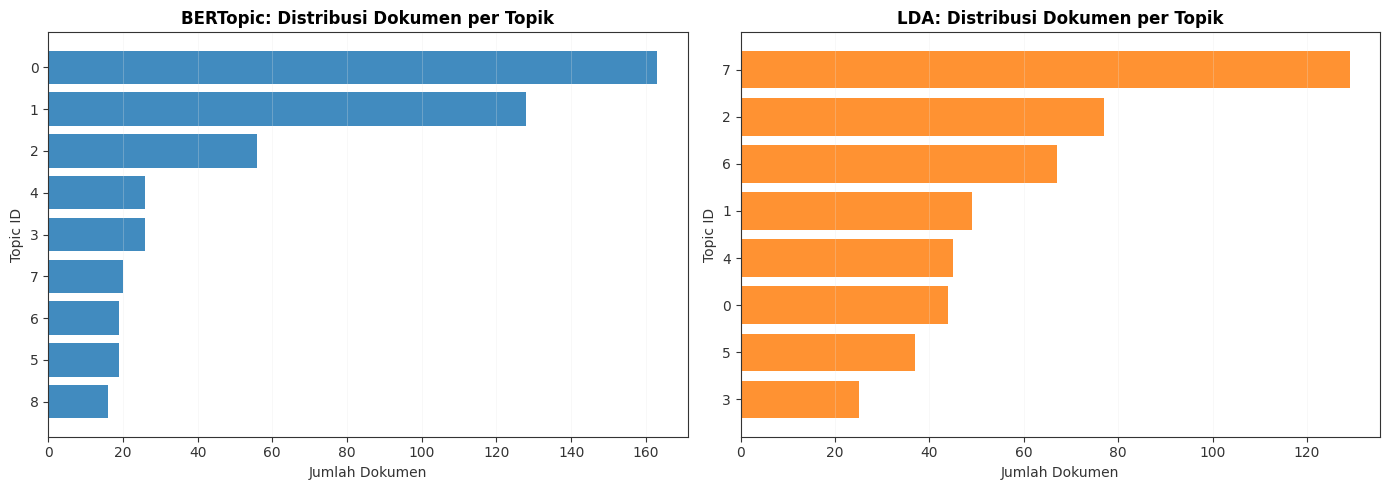


=== WordCloud per Topik (BERTopic) ===


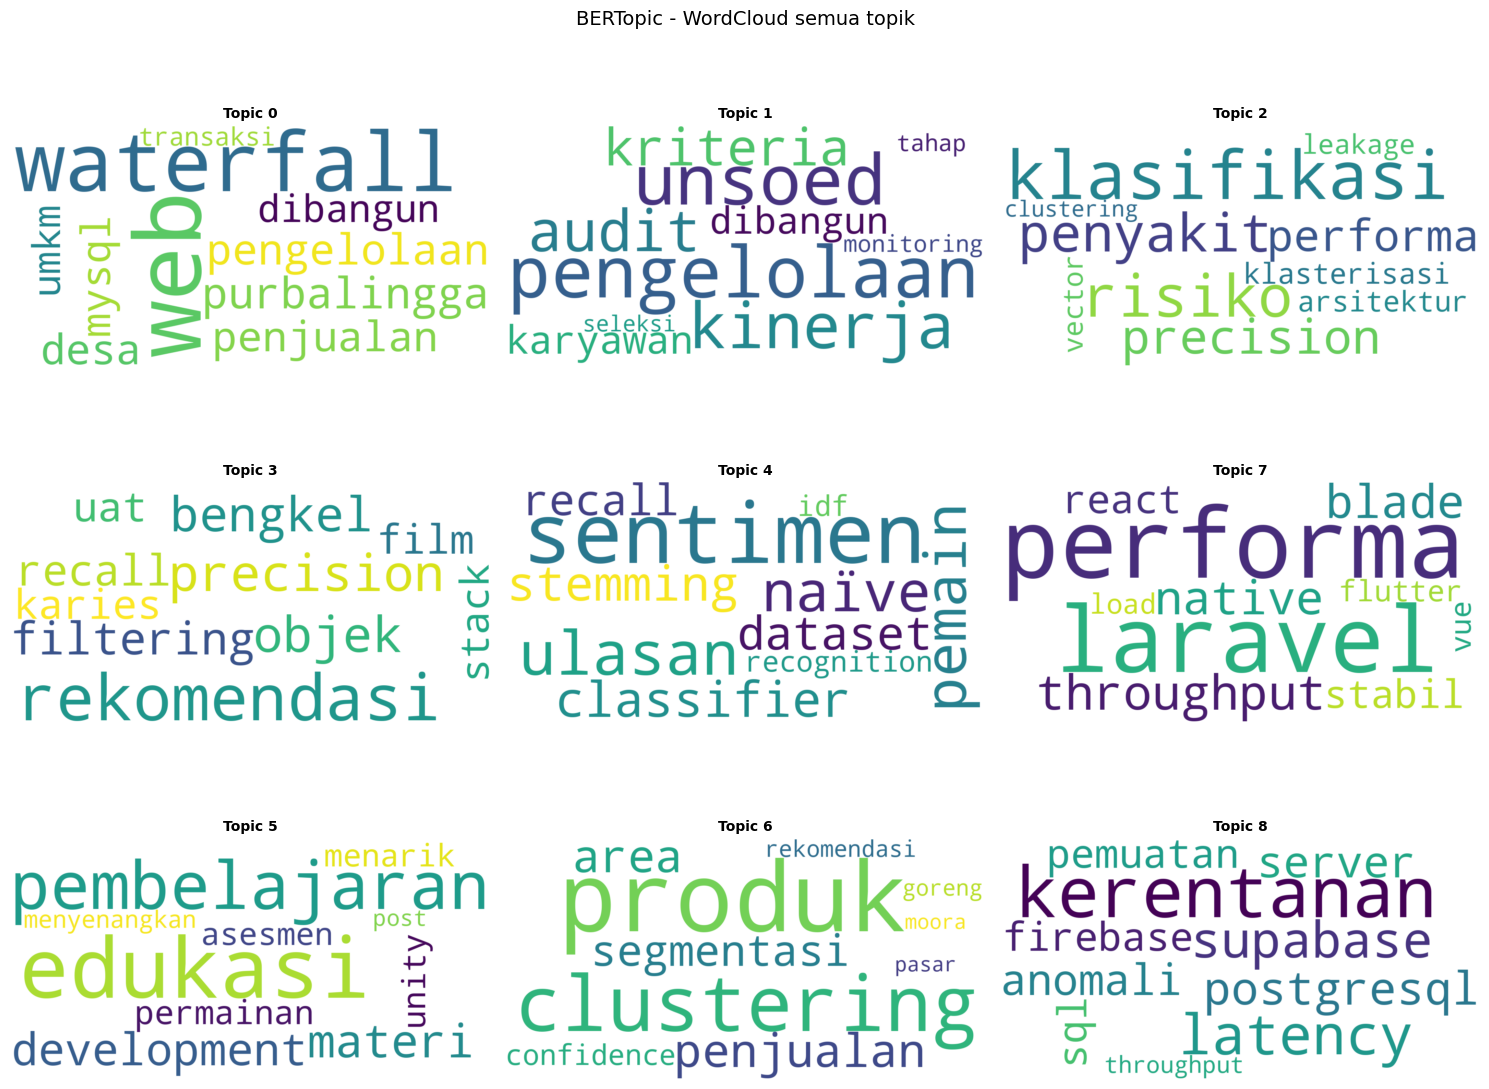


=== WordCloud per Topik (LDA) ===


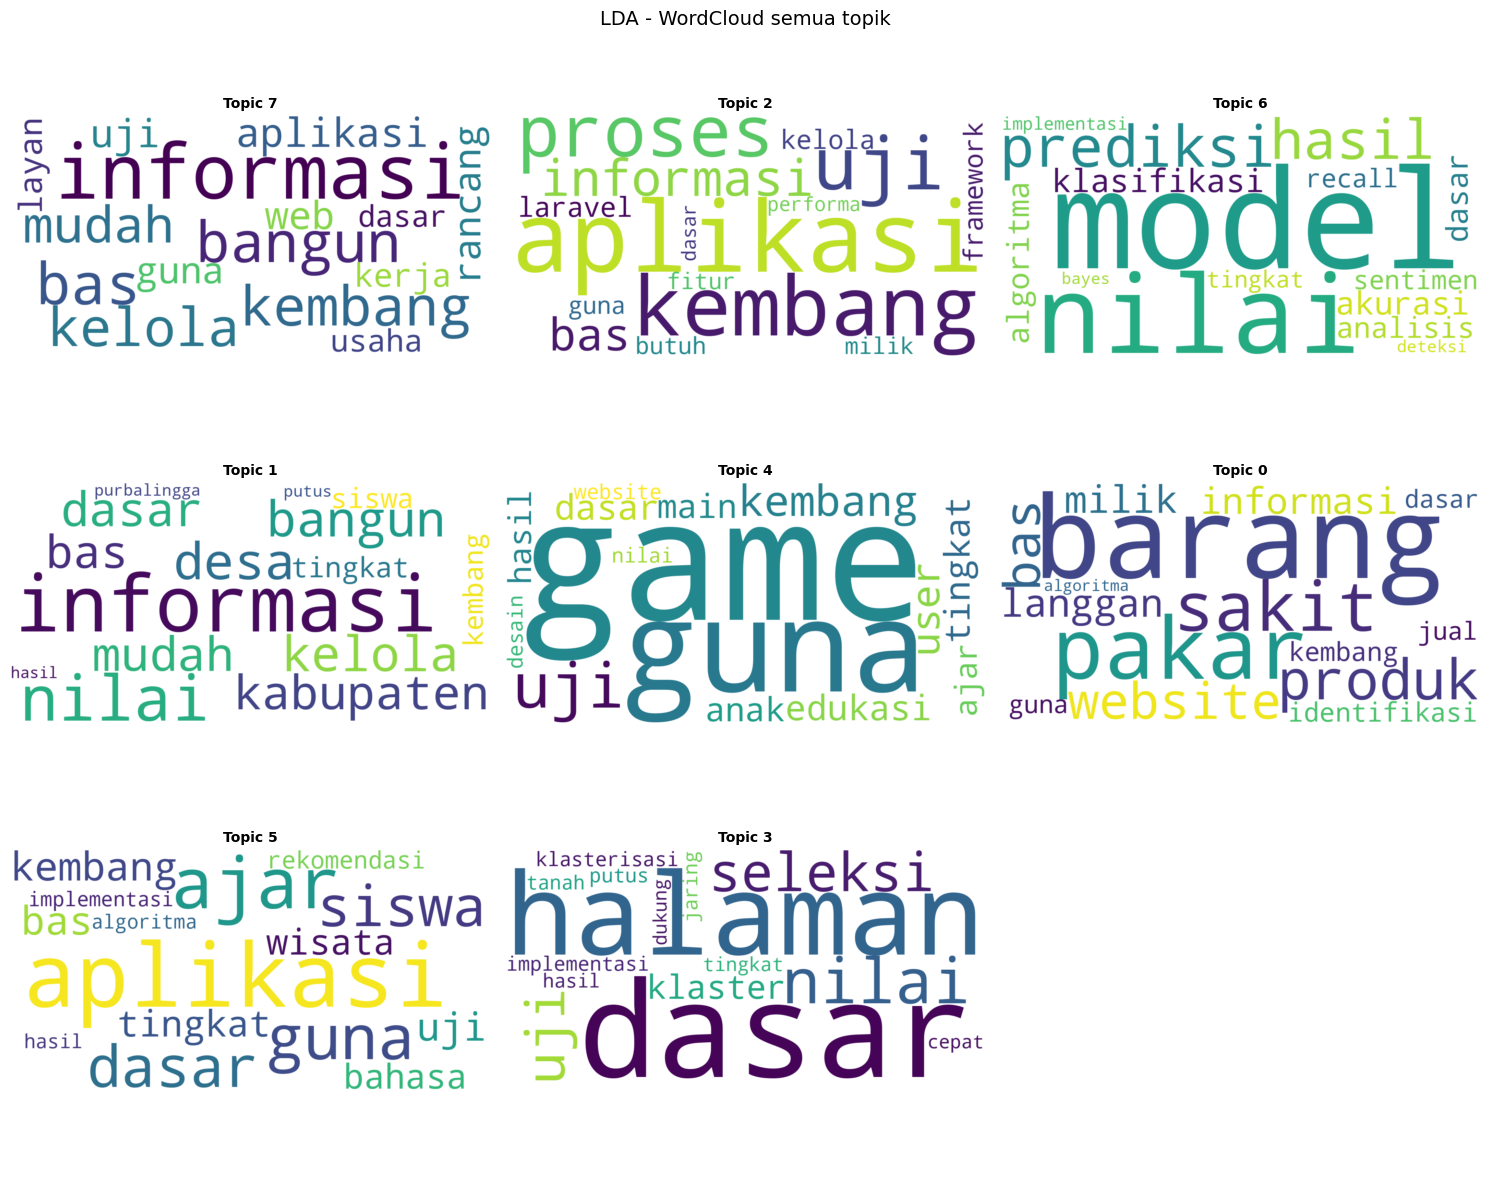


=== Perbandingan Metrics Best Model ===


,model,scenario_id,coherence_cv,topic_diversity,num_topics,model_path
0,BERTopic,bertopic_014,0.4587,0.900,9,/home/galih/MySkripsi/- Aplikasi/my-skripsi/fa...
1,LDA,lda_009,0.3525,0.625,8,/home/galih/MySkripsi/- Aplikasi/my-skripsi/fa...


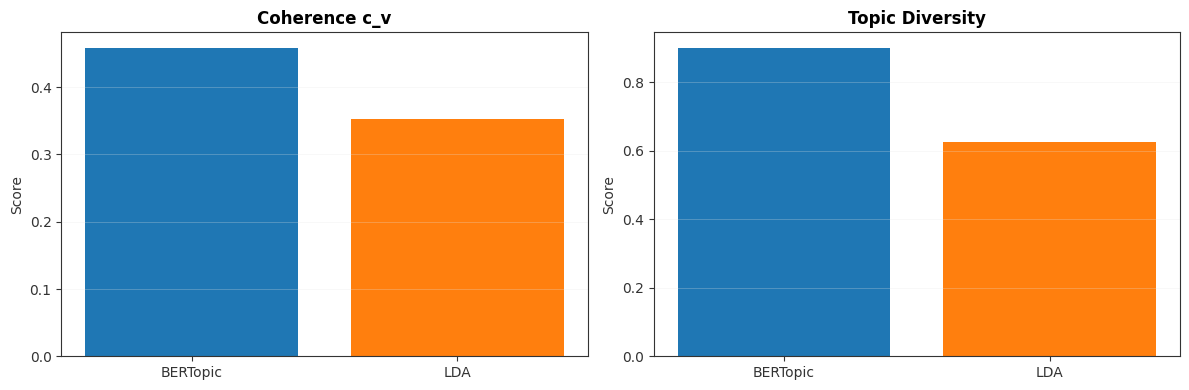


=== DTA BERTopic: Emerging / Stable / Declining ===


9it [02:18, 15.37s/it]

Ringkasan trend:


,trend_label,n_topics
0,declining,1
1,emerging,6
2,stable,2


,topic_id,trend_label,n_periods,start_frequency,end_frequency,slope,relative_slope,keywords_top10
0,0,declining,9,27.0,2.0,-3.366667,-0.185890,"web, waterfall, purbalingga, pengelolaan, desa..."
1,6,emerging,4,2.0,8.0,2.300000,0.484211,"produk, clustering, penjualan, area, segmentas..."
2,7,emerging,4,1.0,2.0,1.400000,0.280000,"performa, laravel, throughput, native, blade, ..."
3,2,emerging,8,1.0,7.0,1.785714,0.255102,"klasifikasi, risiko, penyakit, precision, perf..."
4,3,emerging,7,2.0,3.0,0.821429,0.221154,"rekomendasi, precision, objek, bengkel, filter..."
5,8,emerging,7,1.0,1.0,0.464286,0.203125,"kerentanan, latency, supabase, postgresql, ser..."
6,4,emerging,7,1.0,1.0,0.607143,0.163462,"sentimen, ulasan, pemain, naïve, classifier, s..."
7,1,stable,9,18.0,7.0,0.500000,0.035156,"pengelolaan, unsoed, kinerja, audit, kriteria,..."
8,5,stable,4,2.0,3.0,0.100000,0.021053,"edukasi, pembelajaran, materi, development, pe..."


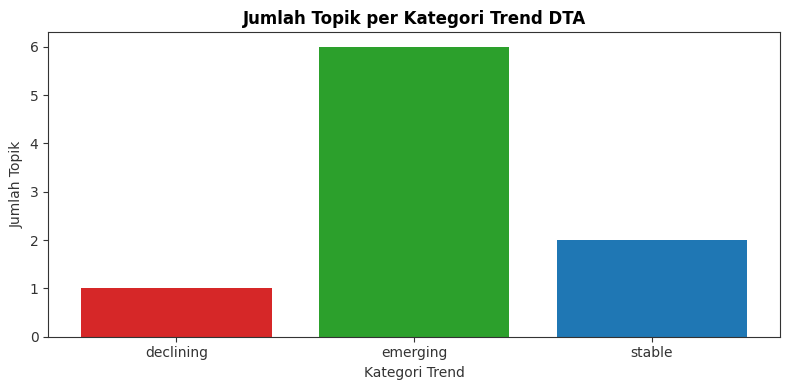

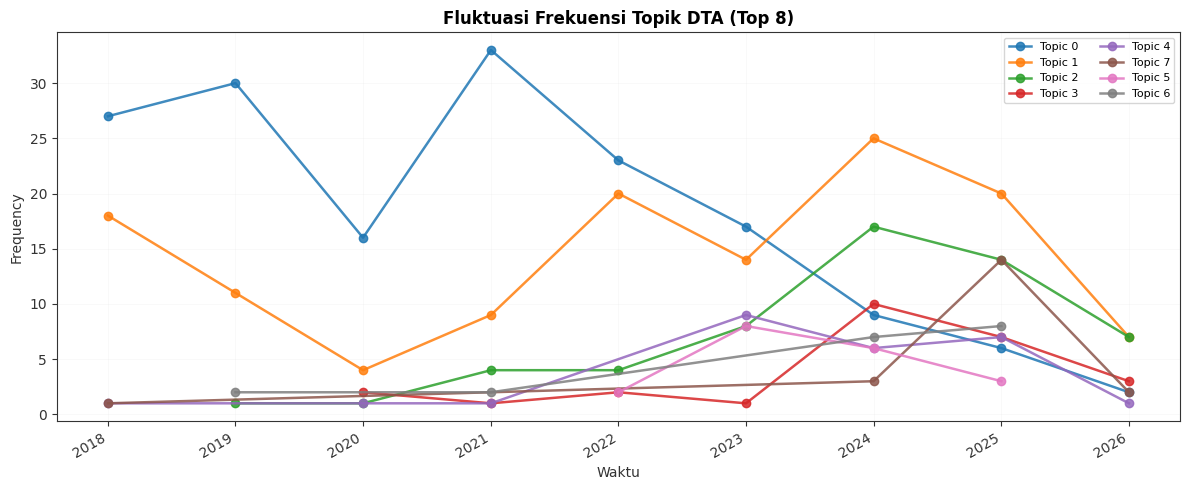

DTA artifacts:
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260413-132545/dta_topics_over_time.csv
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260413-132545/dta_topic_trend_classification.csv


In [7]:
def set_plot_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#333333",
        "axes.labelcolor": "#333333",
        "axes.titleweight": "bold",
        "xtick.color": "#333333",
        "ytick.color": "#333333",
        "grid.color": "#e6e6e6",
        "grid.linestyle": "-",
        "grid.linewidth": 0.6,
    })


MODEL_COLORS = {"bertopic": "#1f77b4", "lda": "#ff7f0e"}
set_plot_style()


def plot_wordcloud_grid(topic_payloads, title_text, max_topics=None, cols=3, colormap="viridis"):
    if WordCloud is None:
        print(f"{title_text} dilewati: package wordcloud belum tersedia.")
        return
    if max_topics is None:
        max_topics = len(topic_payloads)

    payloads = [p for p in topic_payloads[:max_topics] if p.get("freq")]
    if not payloads:
        print(f"{title_text} dilewati: tidak ada topik valid.")
        return

    n = len(payloads)
    cols = max(1, min(cols, n))
    rows = int(math.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, payload in zip(axes, payloads):
        wc = WordCloud(
            width=1400,
            height=700,
            background_color="white",
            colormap=colormap,
            max_words=200,
        ).generate_from_frequencies(payload["freq"])
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(payload.get("title", ""), fontsize=10)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(title_text, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_topic_distribution(ax, topic_df, title, color):
    if topic_df is None or topic_df.empty:
        ax.axis("off")
        ax.set_title(f"{title}: tidak ada data")
        return

    plot_df = (
        topic_df.sort_values("count", ascending=False)
        .head(min(12, len(topic_df)))
        .sort_values("count")
    )
    ax.barh(plot_df["topic_id"].astype(str), plot_df["count"], color=color, alpha=0.85)
    ax.set_title(f"{title}: Distribusi Dokumen per Topik")
    ax.set_xlabel("Jumlah Dokumen")
    ax.set_ylabel("Topic ID")
    ax.grid(axis="x", alpha=0.3)


print("=== Visualisasi BERTopic ===")
bertopic_wc_payloads = []
bertopic_dist_df = None
if final_bertopic is not None:
    b_model = final_bertopic["trainer"].model
    b_info = b_model.get_topic_info().copy()
    if "Topic" in b_info.columns:
        b_info = b_info[b_info["Topic"] != -1].copy()

    if not b_info.empty:
        cols_show = [c for c in ["Topic", "Count", "Name"] if c in b_info.columns]
        display(b_info[cols_show].head(15))

        if "Count" in b_info.columns:
            bertopic_dist_df = (
                b_info[["Topic", "Count"]]
                .rename(columns={"Topic": "topic_id", "Count": "count"})
                .sort_values("count", ascending=False)
            )
            topic_ids = b_info.sort_values("Count", ascending=False)["Topic"].astype(int).tolist()
        else:
            topic_ids = b_info["Topic"].astype(int).tolist()

        for tid in topic_ids:
            words_scores = b_model.get_topic(int(tid)) or []
            freq = {w: float(s or 0.0) for w, s in words_scores[:15] if float(s or 0.0) > 0}
            bertopic_wc_payloads.append({"title": f"Topic {int(tid)}", "freq": freq})
    else:
        print("Topic info BERTopic kosong setelah filter outlier.")
else:
    print("Best BERTopic tidak tersedia.")

print("\n=== Visualisasi LDA ===")
lda_wc_payloads = []
lda_dist_df = None
if final_lda is not None:
    l_trainer = final_lda["trainer"]
    l_model = l_trainer.model

    lda_topic_rows = []
    for topic_id in range(l_model.num_topics):
        topic_words = l_model.show_topic(topic_id, topn=15)
        lda_topic_rows.append({
            "topic_id": int(topic_id),
            "top_words": ", ".join([w for w, _ in topic_words]),
        })

    lda_topic_df = pd.DataFrame(lda_topic_rows)
    display(lda_topic_df.head(15))

    lda_bows = [l_trainer.dictionary.doc2bow(str(doc).split()) for doc in lda_docs]
    dominant_topic_ids = []
    for bow in lda_bows:
        if not bow:
            continue
        dist = l_model.get_document_topics(bow, minimum_probability=0.0)
        if dist:
            dominant_topic_ids.append(int(max(dist, key=lambda x: x[1])[0]))

    topic_counts = Counter(dominant_topic_ids)
    if topic_counts:
        lda_count_df = pd.DataFrame({
            "topic_id": list(topic_counts.keys()),
            "count": list(topic_counts.values()),
        }).sort_values("count", ascending=False)
        lda_dist_df = lda_count_df.copy()
        wc_topic_ids = lda_count_df["topic_id"].astype(int).tolist()
    else:
        wc_topic_ids = list(range(int(l_model.num_topics)))

    for tid in wc_topic_ids:
        words_scores = l_model.show_topic(int(tid), topn=15)
        freq = {w: float(s or 0.0) for w, s in words_scores if float(s or 0.0) > 0}
        lda_wc_payloads.append({"title": f"Topic {int(tid)}", "freq": freq})
else:
    print("Best LDA tidak tersedia.")

print("\n=== Distribusi Dokumen per Topik (Side-by-Side) ===")
if bertopic_dist_df is not None or lda_dist_df is not None:
    if bertopic_dist_df is not None and lda_dist_df is not None:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        plot_topic_distribution(axes[0], bertopic_dist_df, "BERTopic", MODEL_COLORS["bertopic"])
        plot_topic_distribution(axes[1], lda_dist_df, "LDA", MODEL_COLORS["lda"])
        plt.tight_layout()
        plt.show()
    else:
        fig, ax = plt.subplots(1, 1, figsize=(7, 5))
        if bertopic_dist_df is not None:
            plot_topic_distribution(ax, bertopic_dist_df, "BERTopic", MODEL_COLORS["bertopic"])
        else:
            plot_topic_distribution(ax, lda_dist_df, "LDA", MODEL_COLORS["lda"])
        plt.tight_layout()
        plt.show()
else:
    print("Distribusi dilewati: belum ada data.")

print("\n=== WordCloud per Topik (BERTopic) ===")
if bertopic_wc_payloads:
    plot_wordcloud_grid(
        bertopic_wc_payloads,
        "BERTopic - WordCloud semua topik",
        max_topics=None,
        cols=3,
    )
else:
    print("WordCloud BERTopic dilewati: tidak ada topik valid.")

print("\n=== WordCloud per Topik (LDA) ===")
if lda_wc_payloads:
    plot_wordcloud_grid(
        lda_wc_payloads,
        "LDA - WordCloud semua topik",
        max_topics=None,
        cols=3,
    )
else:
    print("WordCloud LDA dilewati: tidak ada topik valid.")

print("\n=== Perbandingan Metrics Best Model ===")
if not final_metrics_df.empty:
    display(final_metrics_df)
    metrics_plot_df = final_metrics_df.copy()
    for col in ["coherence_cv", "topic_diversity"]:
        metrics_plot_df[col] = pd.to_numeric(metrics_plot_df[col], errors="coerce")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = [MODEL_COLORS.get(str(m).lower(), "#333333") for m in metrics_plot_df["model"]]

    axes[0].bar(metrics_plot_df["model"].tolist(), metrics_plot_df["coherence_cv"], color=colors)
    axes[0].set_title("Coherence c_v")
    axes[0].set_ylabel("Score")
    axes[0].grid(axis="y", alpha=0.3)

    axes[1].bar(metrics_plot_df["model"].tolist(), metrics_plot_df["topic_diversity"], color=colors)
    axes[1].set_title("Topic Diversity")
    axes[1].set_ylabel("Score")
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Belum ada metrics best model.")


print("\n=== DTA BERTopic: Emerging / Stable / Declining ===")
dta_paths = []
if final_bertopic is None or timestamps is None:
    print("DTA dilewati: best BERTopic atau timestamps tidak tersedia.")
else:
    dta_model = final_bertopic["trainer"].model
    time_index = pd.to_datetime(pd.Series(timestamps).astype(int).astype(str) + "-01-01", errors="coerce")

    if time_index.isna().any():
        print("DTA dilewati: ada timestamp tidak valid.")
    else:
        try:
            dta_df = dta_model.topics_over_time(bertopic_docs, timestamps=time_index.tolist())
            if dta_df.empty:
                print("DTA menghasilkan dataframe kosong.")
            else:
                dta_df = dta_df.sort_values(["Topic", "Timestamp"]).reset_index(drop=True)
                dta_raw_path = RUN_DIR / "dta_topics_over_time.csv"
                dta_df.to_csv(dta_raw_path, index=False)
                dta_paths.append(dta_raw_path)

                trend_threshold = 0.03
                min_points = 3
                trend_rows = []

                work = dta_df.copy()
                work["Topic"] = pd.to_numeric(work["Topic"], errors="coerce")
                work = work[work["Topic"].notna()].copy()
                work["Topic"] = work["Topic"].astype(int)
                work = work[work["Topic"] != -1].copy()
                work["Frequency"] = pd.to_numeric(work["Frequency"], errors="coerce").fillna(0.0)

                for topic_id, g in work.groupby("Topic"):
                    g = g.sort_values("Timestamp")
                    y = g["Frequency"].to_numpy(dtype=float)
                    x = np.arange(len(g), dtype=float)
                    n_points = len(g)

                    if n_points < min_points:
                        trend_label = "insufficient_data"
                        slope = np.nan
                        relative_slope = np.nan
                    else:
                        slope = float(np.polyfit(x, y, 1)[0])
                        baseline = max(float(np.mean(y)), 1.0)
                        relative_slope = float(slope / baseline)

                        if relative_slope >= trend_threshold and float(y[-1]) >= float(y[0]):
                            trend_label = "emerging"
                        elif relative_slope <= -trend_threshold and float(y[-1]) <= float(y[0]):
                            trend_label = "declining"
                        else:
                            trend_label = "stable"

                    topic_words = dta_model.get_topic(int(topic_id)) or []
                    keywords = ", ".join([w for w, _ in topic_words[:10]])

                    trend_rows.append({
                        "topic_id": int(topic_id),
                        "trend_label": trend_label,
                        "n_periods": int(n_points),
                        "start_frequency": float(y[0]) if n_points else np.nan,
                        "end_frequency": float(y[-1]) if n_points else np.nan,
                        "slope": slope,
                        "relative_slope": relative_slope,
                        "keywords_top10": keywords,
                    })

                trend_df = pd.DataFrame(trend_rows)
                trend_df = trend_df.sort_values(["trend_label", "relative_slope"], ascending=[True, False], na_position="last").reset_index(drop=True)

                trend_path = RUN_DIR / "dta_topic_trend_classification.csv"
                trend_df.to_csv(trend_path, index=False)
                dta_paths.append(trend_path)

                print("Ringkasan trend:")
                summary_df = trend_df.groupby("trend_label", dropna=False).size().reset_index(name="n_topics")
                display(summary_df)
                display(trend_df)

                color_map = {
                    "emerging": "#2ca02c",
                    "stable": "#1f77b4",
                    "declining": "#d62728",
                    "insufficient_data": "#7f7f7f",
                }
                colors = [color_map.get(str(v), "#7f7f7f") for v in summary_df["trend_label"].astype(str)]
                plt.figure(figsize=(8, 4))
                plt.bar(summary_df["trend_label"].astype(str), summary_df["n_topics"], color=colors)
                plt.title("Jumlah Topik per Kategori Trend DTA")
                plt.xlabel("Kategori Trend")
                plt.ylabel("Jumlah Topik")
                plt.tight_layout()
                plt.show()

                top_topics = (
                    work.groupby("Topic", as_index=False)["Frequency"]
                    .sum()
                    .sort_values("Frequency", ascending=False)
                    .head(8)["Topic"]
                    .astype(int)
                    .tolist()
                )

                plt.figure(figsize=(12, 5))
                for tid in top_topics:
                    g = work[work["Topic"] == int(tid)].sort_values("Timestamp")
                    plt.plot(
                        pd.to_datetime(g["Timestamp"], errors="coerce"),
                        g["Frequency"],
                        marker="o",
                        linewidth=1.8,
                        alpha=0.85,
                        label=f"Topic {int(tid)}",
                    )
                plt.title("Fluktuasi Frekuensi Topik DTA (Top 8)")
                plt.xlabel("Waktu")
                plt.ylabel("Frequency")
                plt.xticks(rotation=30, ha="right")
                plt.grid(alpha=0.25)
                plt.legend(loc="best", ncol=2, fontsize=8)
                plt.tight_layout()
                plt.show()

        except Exception as exc:
            print("DTA gagal dijalankan:", exc)

if dta_paths:
    print("DTA artifacts:")
    for p in dta_paths:
        print("-", p)

In [9]:
artifact_rows = []
for p in sorted(RUN_DIR.glob("*")):
    if p.is_file():
        artifact_rows.append({
            "file": p.name,
            "size_kb": round(p.stat().st_size / 1024.0, 2),
        })

artifact_df = pd.DataFrame(artifact_rows).sort_values("file").reset_index(drop=True)
print("Artifact directory:", RUN_DIR)
display(artifact_df)

Artifact directory: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260413-132545


,file,size_kb
0,bertopic_loop_results.csv,21.02
1,bertopic_shared_embeddings.npy,473.12
2,bertopic_topic_keywords_long.csv,4.03
3,best_config.json,6.93
4,best_retrain_metrics.csv,0.44
5,dta_topic_trend_classification.csv,1.42
6,dta_topics_over_time.csv,3.74
7,lda_loop_results.csv,4.91
8,lda_topic_keywords_long.csv,4.69
9,model_comparison_leaderboard.csv,5.70


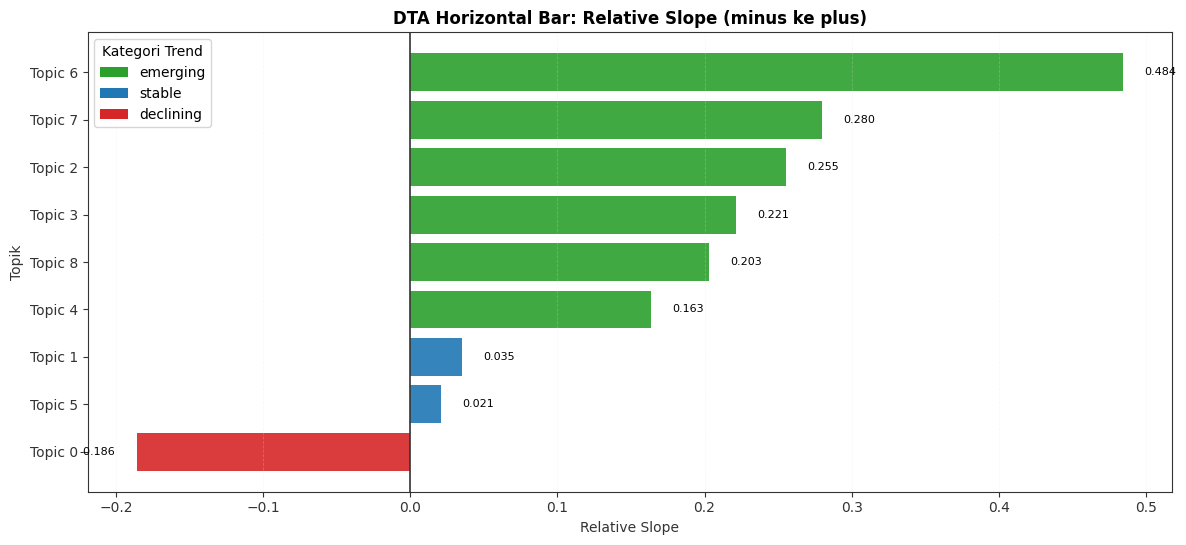

,topic_id,trend_label,relative_slope,slope,start_frequency,end_frequency,keywords_top10
0,0,declining,-0.185890,-3.366667,27.0,2.0,"web, waterfall, purbalingga, pengelolaan, desa..."
1,5,stable,0.021053,0.100000,2.0,3.0,"edukasi, pembelajaran, materi, development, pe..."
2,1,stable,0.035156,0.500000,18.0,7.0,"pengelolaan, unsoed, kinerja, audit, kriteria,..."
3,4,emerging,0.163462,0.607143,1.0,1.0,"sentimen, ulasan, pemain, naïve, classifier, s..."
4,8,emerging,0.203125,0.464286,1.0,1.0,"kerentanan, latency, supabase, postgresql, ser..."
5,3,emerging,0.221154,0.821429,2.0,3.0,"rekomendasi, precision, objek, bengkel, filter..."
6,2,emerging,0.255102,1.785714,1.0,7.0,"klasifikasi, risiko, penyakit, precision, perf..."
7,7,emerging,0.280000,1.400000,1.0,2.0,"performa, laravel, throughput, native, blade, ..."
8,6,emerging,0.484211,2.300000,2.0,8.0,"produk, clustering, penjualan, area, segmentas..."


In [10]:
# Diagram horizontal minus -> plus untuk validasi emerging/stable/declining
from matplotlib.patches import Patch

trend_path = RUN_DIR / "dta_topic_trend_classification.csv"
if not trend_path.exists():
    print(f"File DTA trend belum ditemukan: {trend_path}")
else:
    dta_trend_bar_df = pd.read_csv(trend_path)
    if dta_trend_bar_df.empty:
        print("File DTA trend kosong, tidak ada data untuk diplot.")
    else:
        dta_trend_bar_df = dta_trend_bar_df.copy()
        if "relative_slope" not in dta_trend_bar_df.columns:
            print("Kolom relative_slope tidak ditemukan di file DTA trend.")
        else:
            dta_trend_bar_df["relative_slope"] = pd.to_numeric(
                dta_trend_bar_df["relative_slope"], errors="coerce"
            ).fillna(0.0)

            if "topic_id" not in dta_trend_bar_df.columns:
                dta_trend_bar_df["topic_id"] = np.arange(1, len(dta_trend_bar_df) + 1)

            # Pastikan label trend tersedia; fallback ke threshold slope jika kolom belum ada.
            threshold = 0.03
            if "trend_label" not in dta_trend_bar_df.columns:
                dta_trend_bar_df["trend_label"] = np.where(
                    dta_trend_bar_df["relative_slope"] >= threshold,
                    "emerging",
                    np.where(
                        dta_trend_bar_df["relative_slope"] <= -threshold,
                        "declining",
                        "stable",
                    ),
                )
            else:
                dta_trend_bar_df["trend_label"] = (
                    dta_trend_bar_df["trend_label"]
                    .fillna("stable")
                    .astype(str)
                    .str.strip()
                    .str.lower()
                )

            dta_trend_bar_df = dta_trend_bar_df.sort_values("relative_slope", ascending=True).reset_index(drop=True)
            dta_trend_bar_df["topic_label"] = dta_trend_bar_df["topic_id"].apply(lambda v: f"Topic {int(v)}")

            color_map = {
                "emerging": "#2ca02c",
                "stable": "#1f77b4",
                "declining": "#d62728",
                "insufficient_data": "#7f7f7f",
            }
            bar_colors = [color_map.get(lbl, "#7f7f7f") for lbl in dta_trend_bar_df["trend_label"]]

            fig_height = max(4, 0.45 * len(dta_trend_bar_df) + 1.5)
            fig, ax = plt.subplots(figsize=(12, fig_height))
            bars = ax.barh(
                dta_trend_bar_df["topic_label"],
                dta_trend_bar_df["relative_slope"],
                color=bar_colors,
                alpha=0.9,
            )

            ax.axvline(0, color="#333333", linewidth=1.2, linestyle="-")
            ax.set_title("DTA Horizontal Bar: Relative Slope (minus ke plus)")
            ax.set_xlabel("Relative Slope")
            ax.set_ylabel("Topik")
            ax.grid(axis="x", alpha=0.25, linestyle="--")

            max_abs = float(dta_trend_bar_df["relative_slope"].abs().max() or 0.0)
            x_pad = max(max_abs * 0.03, 0.003)
            for bar, value in zip(bars, dta_trend_bar_df["relative_slope"]):
                x_pos = value + x_pad if value >= 0 else value - x_pad
                ha = "left" if value >= 0 else "right"
                ax.text(
                    x_pos,
                    bar.get_y() + bar.get_height() / 2,
                    f"{value:.3f}",
                    va="center",
                    ha=ha,
                    fontsize=8,
                )

            legend_order = ["emerging", "stable", "declining", "insufficient_data"]
            trend_set = set(dta_trend_bar_df["trend_label"].tolist())
            legend_handles = [
                Patch(facecolor=color_map[label], edgecolor="none", label=label)
                for label in legend_order
                if label in trend_set
            ]
            if legend_handles:
                ax.legend(handles=legend_handles, title="Kategori Trend", loc="best")

            plt.tight_layout()
            plt.show()

            show_cols = [
                col
                for col in [
                    "topic_id",
                    "trend_label",
                    "relative_slope",
                    "slope",
                    "start_frequency",
                    "end_frequency",
                    "keywords_top10",
                ]
                if col in dta_trend_bar_df.columns
            ]
            display(dta_trend_bar_df[show_cols])

In [11]:
# Backfill kolom outlier before/after tanpa rerun loop tuning penuh.
if "bertopic_success_payloads" not in globals() or not bertopic_success_payloads:
    print("Tidak ada bertopic_success_payloads di kernel saat ini. Jalankan ulang Cell 9 (Loop Tuning) untuk regenerasi.")
else:
    if "bertopic_results_df" not in globals() or bertopic_results_df is None or bertopic_results_df.empty:
        print("bertopic_results_df tidak tersedia/empty. Jalankan ulang Cell 9 (Loop Tuning).")
    else:
        before_after_map = {}
        for payload in bertopic_success_payloads:
            scenario = payload.get("scenario", {}) or {}
            train_result = payload.get("train_result", {}) or {}
            sid = scenario.get("scenario_id")
            if not sid:
                continue
            before_after_map[sid] = {
                "num_outliers_before_reduce": train_result.get("num_outliers_before_reduce"),
                "num_outliers_after_reduce": train_result.get("num_outliers"),
            }

        patched_df = bertopic_results_df.copy()
        patched_df["num_outliers_before_reduce"] = patched_df["scenario_id"].map(
            lambda sid: (before_after_map.get(sid) or {}).get("num_outliers_before_reduce")
        )
        patched_df["num_outliers_after_reduce"] = patched_df["scenario_id"].map(
            lambda sid: (before_after_map.get(sid) or {}).get("num_outliers_after_reduce")
        )

        # Pertahankan kompatibilitas lama: num_outliers tetap menunjuk nilai setelah reduce.
        patched_df["num_outliers"] = patched_df["num_outliers_after_reduce"].fillna(patched_df.get("num_outliers"))

        total_docs = len(bertopic_docs) if "bertopic_docs" in globals() else None
        if total_docs and total_docs > 0:
            patched_df["outlier_pct_before_reduce"] = (
                pd.to_numeric(patched_df["num_outliers_before_reduce"], errors="coerce").fillna(0.0)
                / float(total_docs)
                * 100.0
            ).round(2)
            patched_df["outlier_pct_after_reduce"] = (
                pd.to_numeric(patched_df["num_outliers_after_reduce"], errors="coerce").fillna(0.0)
                / float(total_docs)
                * 100.0
            ).round(2)

        export_path = globals().get("bertopic_results_path", RUN_DIR / "bertopic_loop_results.csv")
        patched_df.to_csv(export_path, index=False)
        bertopic_results_df = patched_df

        show_cols = [
            c
            for c in [
                "scenario_id",
                "num_outliers_before_reduce",
                "num_outliers_after_reduce",
                "num_outliers",
                "outlier_pct_before_reduce",
                "outlier_pct_after_reduce",
                "outlier_pct",
            ]
            if c in patched_df.columns
        ]
        print("BERTopic loop results diperbarui:", export_path)
        display(patched_df[show_cols].head(10))

BERTopic loop results diperbarui: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260413-132545/bertopic_loop_results.csv


,scenario_id,num_outliers_before_reduce,num_outliers_after_reduce,num_outliers,outlier_pct_before_reduce,outlier_pct_after_reduce,outlier_pct
0,bertopic_014,83,0,0,17.55,0.0,0.0
1,bertopic_009,62,0,0,13.11,0.0,0.0
2,bertopic_018,72,0,0,15.22,0.0,0.0
3,bertopic_007,83,0,0,17.55,0.0,0.0
4,bertopic_012,59,0,0,12.47,0.0,0.0
5,bertopic_011,81,0,0,17.12,0.0,0.0
6,bertopic_019,81,0,0,17.12,0.0,0.0
7,bertopic_004,141,0,0,29.81,0.0,0.0
8,bertopic_002,85,0,0,17.97,0.0,0.0
9,bertopic_016,55,0,0,11.63,0.0,0.0
